# Avoided Costs

This notebook keeps the avoided-cost tables, the existing claims cost data, and a 13-year EUL rollup for the calculated 8760 benefits.

In [154]:
from pathlib import Path
import csv
import json
import importlib
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import data_loader

CLAIMS_DATA_PATH = Path("..").resolve() / "claims_data_swwh028_222324.csv"
SWWH028_DATA_PATH = Path("SWWH028.xlsx")
MODEL_RUNS_ES_DIR = Path("Model Runs ES") / "corrected with cap"

# Optional batch-run filters. Use None for every available option, or lists like ["6", "7"] / ["Hotel", "MFm"].
RUN_CLIMATE_ZONES = ["8","9"] #["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"] or None
RUN_BUILDING_TYPES = ["Hotel"] #["Grocery", "Hotel", "MFm", "Hsp"]
RUN_BASELINE_TYPES = ["CODE", "EXISTING"]
RUN_HP_COPS = [3.0, 4.3]

# Model Runs ES raw rows have an unquoted comma in Baseline ID in some exports, so read by raw position.
# UEC = hourly kW/kBtuh; summing 8,760 one-hour rows gives annual kWh/kBtuh.
# UECproportion is the hourly share of annual electric use and should sum to 1.
# Total capacity is system capacity in Btu/h; divide by 1,000 for kBtuh.
MODEL_ES_ELECTRIC_KW_PER_KBTUH_COL_INDEX = 12
MODEL_ES_ELECTRIC_UEC_PROPORTION_COL_INDEX = 13
MODEL_ES_EXISTING_THERM_PER_KBTUH_COL_INDEX = 15
MODEL_ES_STANDARD_THERM_PER_KBTUH_COL_INDEX = 16
MODEL_ES_TOTAL_CAPACITY_BTUH_COL_INDEX = 17
MODEL_ES_NUM_UNITS_COL_INDEX = 18

BUILDING_TYPE_ALIASES = {
    "Gro": "Grocery",
    "Grocery": "Grocery",
    "Htl": "Hotel",
    "HTL": "Hotel",
    "Hotel": "Hotel",
    "Lodging - Hotel": "Hotel",
    "MFm": "MFm",
    "Mfm": "MFm",
    "Multifamily": "MFm",
    "Hsp": "Hsp",
    "Hospital": "Hsp",
    "Health/Medical - Hospital": "Hsp",
    "Nrs": "Nrs",
    "NRS": "Nrs",
    "Nursing": "Nrs",
    "Nursing Home": "Nrs",
    "Health/Medical - Nursing Home": "Nrs",
}
MODEL_ES_BUILDING_ALIASES = {
    "Grocery": "Gro",
    "Hotel": "Htl",
    "MFm": "MFm",
    "Hsp": "Hsp",
    "Nrs": "Nrs",
}


def normalize_building_type(value):
    text = str(value).strip()
    return BUILDING_TYPE_ALIASES.get(text, text)


# Backward-compatible name for cells that still call the old helper.
def normalize_qea_capacity_building(value):
    return normalize_building_type(value)


def normalize_climate_zone(value):
    match = re.search(r"\d+", str(value))
    return str(int(match.group())) if match else str(value).strip()


def _selected_filter_set(values, normalizer):
    if values is None or values == "ALL":
        return None
    if isinstance(values, (str, int, float)):
        values = [values]
    return {normalizer(value) for value in values}


def normalize_hp_cop(value):
    return round(float(value), 3)


def parse_model_file_hp_cop(model_path):
    text = Path(model_path).name
    measure_part = text.rsplit("_", 2)[0]
    if not re.search(r"(?:COP|UEF)", measure_part, flags=re.IGNORECASE):
        raise ValueError(f"Could not parse HP COP/UEF from model file name: {text}")
    numeric_values = re.findall(r"\d+(?:\.\d+)?", measure_part)
    if not numeric_values:
        raise ValueError(f"Could not parse HP COP/UEF from model file name: {text}")
    return normalize_hp_cop(numeric_values[-1])


def load_model_es_modeled_capacity(model_runs_dir=MODEL_RUNS_ES_DIR):
    raw_usecols = [
        1,  # BldgType
        4,  # BldgLoc
        MODEL_ES_TOTAL_CAPACITY_BTUH_COL_INDEX,
        MODEL_ES_NUM_UNITS_COL_INDEX,
    ]
    capacity_frames = []
    for model_path in sorted(Path(model_runs_dir).glob("*.csv")):
        expected_model_building_type = model_path.stem.rsplit("_", 1)[-1]
        raw = pd.read_csv(model_path, usecols=raw_usecols)
        raw = raw.iloc[:, :4].copy()
        raw.columns = ["model_building_type", "climate_zone", "total_capacity_btuh", "num_units"]
        raw["model_building_type"] = raw["model_building_type"].astype(str).str.strip()
        raw = raw[raw["model_building_type"].eq(expected_model_building_type)].copy()
        raw["building_type"] = raw["model_building_type"].map(normalize_building_type)
        raw["climate_zone"] = raw["climate_zone"].map(normalize_climate_zone)
        raw["modeled_capacity_kbtuh"] = pd.to_numeric(raw["total_capacity_btuh"], errors="coerce") / 1000
        raw["modeled_unit_count"] = pd.to_numeric(raw["num_units"], errors="coerce")
        raw = raw[
            raw["building_type"].isin(MODEL_ES_BUILDING_ALIASES)
            & raw["climate_zone"].ne("")
            & raw["modeled_capacity_kbtuh"].notna()
        ].copy()
        if raw.empty:
            continue
        capacity_by_pair = raw.groupby(["climate_zone", "building_type", "model_building_type"], as_index=False).agg(
            modeled_capacity_kbtuh=("modeled_capacity_kbtuh", "median"),
            modeled_unit_count=("modeled_unit_count", "median"),
        )
        capacity_by_pair["hp_cop"] = parse_model_file_hp_cop(model_path)
        capacity_by_pair["model_file"] = model_path.name
        capacity_frames.append(capacity_by_pair)

    if not capacity_frames:
        raise FileNotFoundError(f"No Model Runs ES capacity rows found in {Path(model_runs_dir).resolve()}.")

    capacity = pd.concat(capacity_frames, ignore_index=True)
    return capacity.groupby(["climate_zone", "building_type", "hp_cop"], as_index=False).agg(
        modeled_capacity_kbtuh=("modeled_capacity_kbtuh", "median"),
        modeled_unit_count=("modeled_unit_count", "median"),
        model_building_type=("model_building_type", lambda values: ", ".join(sorted(set(map(str, values))))),
        capacity_model_files=("model_file", lambda values: ", ".join(sorted(set(map(str, values))))),
    ).sort_values(["building_type", "hp_cop", "climate_zone"], ignore_index=True)


MODEL_ES_MODELED_CAPACITY = load_model_es_modeled_capacity()


def get_model_es_modeled_capacity_record(climate_zone, building_type, hp_cop=None):
    climate_zone_key = normalize_climate_zone(climate_zone)
    building_type_key = normalize_building_type(building_type)
    matched = MODEL_ES_MODELED_CAPACITY[
        MODEL_ES_MODELED_CAPACITY["climate_zone"].eq(climate_zone_key)
        & MODEL_ES_MODELED_CAPACITY["building_type"].eq(building_type_key)
    ]
    if hp_cop is not None:
        matched = matched[matched["hp_cop"].eq(normalize_hp_cop(hp_cop))]
    if matched.empty:
        available = ", ".join(
            f"CZ{row.climate_zone} {row.building_type} COP {row.hp_cop:g}"
            for row in MODEL_ES_MODELED_CAPACITY.sort_values(["building_type", "hp_cop", "climate_zone"]).itertuples()
        )
        raise KeyError(f"No Model Runs ES capacity found for CZ{climate_zone_key} {building_type_key} COP {hp_cop}. Available pairs: {available}")
    return matched.iloc[0]


def get_model_es_modeled_capacity_kbtuh(climate_zone, building_type, hp_cop=None):
    return float(get_model_es_modeled_capacity_record(climate_zone, building_type, hp_cop)["modeled_capacity_kbtuh"])


# Backward-compatible name for cells that still call the old helper.
def get_qea_modeled_capacity_kbtuh(climate_zone, building_type, hp_cop=None):
    return get_model_es_modeled_capacity_kbtuh(climate_zone, building_type, hp_cop)


def model_es_baseline_column_for_type(baseline_type):
    baseline_type_key = str(baseline_type).strip().upper()
    if baseline_type_key == "EXISTING":
        return "Existing", MODEL_ES_EXISTING_THERM_PER_KBTUH_COL_INDEX
    if baseline_type_key == "CODE":
        return "Standard", MODEL_ES_STANDARD_THERM_PER_KBTUH_COL_INDEX
    raise ValueError(f"Unsupported Model Runs ES baseline type: {baseline_type}")


MODEL_ES_LOAD_SHAPE_CACHE = {}


def _get_model_es_hourly_per_kbtuh(climate_zone, building_type, baseline_type, hp_cop=None):
    climate_zone_key = normalize_climate_zone(climate_zone)
    building_type_key = normalize_building_type(building_type)
    hp_cop_key = normalize_hp_cop(hp_cop if hp_cop is not None else SELECTED_HP_COP)
    model_building_type = MODEL_ES_BUILDING_ALIASES.get(building_type_key, building_type_key)
    baseline_source, therm_col_index = model_es_baseline_column_for_type(baseline_type)
    cache_key = (climate_zone_key, building_type_key, baseline_source, hp_cop_key)
    if cache_key in MODEL_ES_LOAD_SHAPE_CACHE:
        return MODEL_ES_LOAD_SHAPE_CACHE[cache_key]

    raw_usecols = [
        1,  # BldgType
        4,  # BldgLoc
        11,  # Hour of Year
        MODEL_ES_ELECTRIC_KW_PER_KBTUH_COL_INDEX,
        MODEL_ES_ELECTRIC_UEC_PROPORTION_COL_INDEX,
        MODEL_ES_EXISTING_THERM_PER_KBTUH_COL_INDEX,
        MODEL_ES_STANDARD_THERM_PER_KBTUH_COL_INDEX,
        MODEL_ES_TOTAL_CAPACITY_BTUH_COL_INDEX,
        MODEL_ES_NUM_UNITS_COL_INDEX,
    ]
    model_frames = []
    for model_path in sorted(MODEL_RUNS_ES_DIR.glob(f"*_{model_building_type}.csv")):
        if parse_model_file_hp_cop(model_path) != hp_cop_key:
            continue
        raw = pd.read_csv(model_path, usecols=raw_usecols)
        raw = raw.iloc[:, :9].copy()
        raw.columns = [
            "model_building_type",
            "climate_zone",
            "hour",
            "electric_kw_per_kbtuh",
            "electric_uec_proportion",
            "existing_gas_therms_per_kbtuh",
            "standard_gas_therms_per_kbtuh",
            "total_capacity_btuh",
            "num_units",
        ]
        raw = raw[
            raw["model_building_type"].astype(str).str.strip().eq(model_building_type)
            & raw["climate_zone"].map(normalize_climate_zone).eq(climate_zone_key)
        ].copy()
        if raw.empty:
            continue
        raw["model_file"] = model_path.name
        model_frames.append(raw)

    if not model_frames:
        raise FileNotFoundError(
            f"No Model Runs ES rows found for CZ{climate_zone_key} {building_type_key} "
            f"(model building={model_building_type}, baseline={baseline_source}, COP={hp_cop_key:g})."
        )

    model_rows = pd.concat(model_frames, ignore_index=True)
    therm_column = "existing_gas_therms_per_kbtuh" if therm_col_index == MODEL_ES_EXISTING_THERM_PER_KBTUH_COL_INDEX else "standard_gas_therms_per_kbtuh"
    model_rows["hour"] = pd.to_numeric(model_rows["hour"], errors="coerce")
    model_rows["electric_kw_per_kbtuh"] = pd.to_numeric(model_rows["electric_kw_per_kbtuh"], errors="coerce")
    model_rows["electric_uec_proportion"] = pd.to_numeric(model_rows["electric_uec_proportion"], errors="coerce")
    model_rows["gas_therms_per_kbtuh"] = pd.to_numeric(model_rows[therm_column], errors="coerce")
    model_rows["modeled_capacity_kbtuh"] = pd.to_numeric(model_rows["total_capacity_btuh"], errors="coerce") / 1000
    model_rows["modeled_unit_count"] = pd.to_numeric(model_rows["num_units"], errors="coerce")
    model_rows = model_rows[
        model_rows["hour"].between(1, 8760)
        & model_rows["electric_kw_per_kbtuh"].notna()
        & model_rows["electric_uec_proportion"].notna()
        & model_rows["gas_therms_per_kbtuh"].notna()
        & model_rows["modeled_capacity_kbtuh"].notna()
    ].copy()
    model_rows["hour"] = model_rows["hour"].astype(int)

    hourly_per_file = model_rows.groupby(["model_file", "hour"], as_index=False).agg(
        electric_kw_per_kbtuh=("electric_kw_per_kbtuh", "sum"),
        electric_uec_proportion=("electric_uec_proportion", "sum"),
        gas_therms_per_kbtuh=("gas_therms_per_kbtuh", "sum"),
        modeled_capacity_kbtuh=("modeled_capacity_kbtuh", "median"),
        modeled_unit_count=("modeled_unit_count", "median"),
    )
    hourly = hourly_per_file.groupby("hour", as_index=False).agg(
        electric_kw_per_kbtuh=("electric_kw_per_kbtuh", "median"),
        electric_uec_proportion=("electric_uec_proportion", "median"),
        gas_therms_per_kbtuh=("gas_therms_per_kbtuh", "median"),
    )
    if len(hourly) != 8760:
        raise ValueError(f"Expected 8,760 Model Runs ES hours, found {len(hourly)} for CZ{climate_zone_key} {building_type_key}.")

    uec_proportion_by_file = hourly_per_file.groupby("model_file")["electric_uec_proportion"].sum()
    metadata = {
        "baseline_source": baseline_source,
        "model_building_type": model_building_type,
        "hp_cop": hp_cop_key,
        "model_run_count": int(hourly_per_file["model_file"].nunique()),
        "model_files": ", ".join(sorted(hourly_per_file["model_file"].unique())),
        "modeled_capacity_kbtuh": float(hourly_per_file["modeled_capacity_kbtuh"].median()),
        "modeled_unit_count": float(hourly_per_file["modeled_unit_count"].median()),
        "uec_proportion_sum_min": float(uec_proportion_by_file.min()),
        "uec_proportion_sum_max": float(uec_proportion_by_file.max()),
    }
    MODEL_ES_LOAD_SHAPE_CACHE[cache_key] = (hourly, metadata)
    return MODEL_ES_LOAD_SHAPE_CACHE[cache_key]


def read_model_es_load_shapes(climate_zone, building_type, baseline_type, capacity_kbtuh=None, hp_cop=None):
    climate_zone_key = normalize_climate_zone(climate_zone)
    building_type_key = normalize_building_type(building_type)
    hp_cop_key = normalize_hp_cop(hp_cop if hp_cop is not None else SELECTED_HP_COP)
    capacity_kbtuh = float(capacity_kbtuh if capacity_kbtuh is not None else get_model_es_modeled_capacity_kbtuh(climate_zone_key, building_type_key, hp_cop_key))
    hourly, metadata = _get_model_es_hourly_per_kbtuh(climate_zone_key, building_type_key, baseline_type, hp_cop_key)

    gas_load = hourly[["hour", "gas_therms_per_kbtuh"]].copy()
    gas_load["baseline_gas_therms"] = gas_load["gas_therms_per_kbtuh"] * capacity_kbtuh
    gas_load["baseline_gas_btu"] = gas_load["baseline_gas_therms"] * data_loader.BTU_PER_THERM
    gas_load = gas_load[["hour", "baseline_gas_btu", "baseline_gas_therms"]]

    elec_load = hourly[["hour", "electric_kw_per_kbtuh", "electric_uec_proportion"]].copy()
    electric_kw_per_kbtuh_load = elec_load["electric_kw_per_kbtuh"]
    if electric_kw_per_kbtuh_load.sum() < 0:
        electric_kw_per_kbtuh_load = -electric_kw_per_kbtuh_load
    elec_load["hpwh_electric_kw"] = electric_kw_per_kbtuh_load * capacity_kbtuh
    elec_load["hpwh_electric_kwh"] = elec_load["hpwh_electric_kw"]
    elec_load = elec_load[["hour", "hpwh_electric_kw", "hpwh_electric_kwh", "electric_uec_proportion"]]

    scenario_metadata = metadata.copy()
    scenario_metadata["capacity_kbtuh_used"] = capacity_kbtuh
    return gas_load, elec_load, scenario_metadata


def build_scenario_runs(climate_zones=None, building_types=None, baseline_types=None, hp_cops=None):
    climate_zone_filter = _selected_filter_set(climate_zones, normalize_climate_zone)
    building_type_filter = _selected_filter_set(building_types, normalize_building_type)
    hp_cop_filter = _selected_filter_set(hp_cops, normalize_hp_cop)
    baseline_type_values = baseline_types or ["CODE", "EXISTING"]
    capacity = MODEL_ES_MODELED_CAPACITY.copy()
    if climate_zone_filter is not None:
        capacity = capacity[capacity["climate_zone"].isin(climate_zone_filter)]
    if building_type_filter is not None:
        capacity = capacity[capacity["building_type"].isin(building_type_filter)]
    if hp_cop_filter is not None:
        capacity = capacity[capacity["hp_cop"].isin(hp_cop_filter)]
    scenarios = [
        {"climate_zone": row.climate_zone, "building_type": row.building_type, "hp_cop": row.hp_cop, "baseline_type": str(baseline_type).strip().upper()}
        for row in capacity.sort_values(["building_type", "hp_cop", "climate_zone"]).itertuples()
        for baseline_type in baseline_type_values
    ]
    if not scenarios:
        available = MODEL_ES_MODELED_CAPACITY[["climate_zone", "building_type", "hp_cop"]].drop_duplicates().sort_values(["building_type", "hp_cop", "climate_zone"])
        raise ValueError(
            "No scenario runs matched RUN_CLIMATE_ZONES/RUN_BUILDING_TYPES. "
            f"Available pairs:\n{available.to_string(index=False)}"
        )
    return scenarios


SCENARIO_RUNS = build_scenario_runs(RUN_CLIMATE_ZONES, RUN_BUILDING_TYPES, RUN_BASELINE_TYPES, RUN_HP_COPS)

SELECTED_CLIMATE_ZONE = SCENARIO_RUNS[0]["climate_zone"]
SELECTED_BUILDING_TYPE = SCENARIO_RUNS[0]["building_type"]
SELECTED_BASELINE_TYPE = SCENARIO_RUNS[0]["baseline_type"]
SELECTED_HP_COP = SCENARIO_RUNS[0].get("hp_cop", 4.3)
SELECTED_MODELED_HP_HEATING_CAPACITY_KBTUH = get_model_es_modeled_capacity_kbtuh(SELECTED_CLIMATE_ZONE, SELECTED_BUILDING_TYPE, SELECTED_HP_COP)
SELECTED_MODELED_UNIT_COUNT = float(get_model_es_modeled_capacity_record(SELECTED_CLIMATE_ZONE, SELECTED_BUILDING_TYPE, SELECTED_HP_COP)["modeled_unit_count"])
SELECTED_DISCOUNT_RATE = 0.072967
SELECTED_CLAIMS_YEAR = "2024"
SELECTED_OFFERING_TYPE = "L"
SELECTED_TRC_COST_MATCH_COUNT = 5

DEFAULT_SCENARIO_OPTIONS = {
    "hp_cop": SELECTED_HP_COP,
    "modeled_hp_heating_capacity_kbtuh": SELECTED_MODELED_HP_HEATING_CAPACITY_KBTUH,
    "modeled_unit_count": SELECTED_MODELED_UNIT_COUNT,
    "discount_rate": SELECTED_DISCOUNT_RATE,
    "claims_year": SELECTED_CLAIMS_YEAR,
    "offering_type": SELECTED_OFFERING_TYPE,
    "trc_cost_match_count": SELECTED_TRC_COST_MATCH_COUNT,
}

data_loader = importlib.reload(data_loader)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)




## Load Data

In [155]:
selected_modeled_capacity_kbtuh = get_model_es_modeled_capacity_kbtuh(SELECTED_CLIMATE_ZONE, SELECTED_BUILDING_TYPE, SELECTED_HP_COP)
SELECTED_MODELED_HP_HEATING_CAPACITY_KBTUH = selected_modeled_capacity_kbtuh
SELECTED_MODELED_UNIT_COUNT = 1.0
selected_hpwh_workbook = MODEL_RUNS_ES_DIR
claims_building_type_regex = data_loader.get_claims_building_type_regex(SELECTED_BUILDING_TYPE)
claims_offering_suffix_pattern = rf"{re.escape(str(SELECTED_OFFERING_TYPE).strip())}$"
claims_year_filter = str(SELECTED_CLAIMS_YEAR).strip()
claims_climate_zone_filter = str(SELECTED_CLIMATE_ZONE).strip()
if claims_climate_zone_filter.isdigit():
    claims_climate_zone_regex = rf"^{re.escape(claims_climate_zone_filter)}[A-Za-z]?$"
else:
    claims_climate_zone_regex = rf"^{re.escape(claims_climate_zone_filter)}$"
selected_baseline_type = str(SELECTED_BASELINE_TYPE).strip().upper()
if selected_baseline_type == "CODE":
    selected_measure_application_type = "NR"
    claims_measure_application_regex = r"(?:^NR$|Normal\s+Replacement)"
elif selected_baseline_type == "EXISTING":
    selected_measure_application_type = "AR"
    claims_measure_application_regex = r"(?:^AR$|Accelerated\s+Replacement)"
else:
    raise ValueError(f"Unsupported baseline type for claims filtering: {SELECTED_BASELINE_TYPE}")
SELECTED_MEASURE_APPLICATION_TYPE = selected_measure_application_type

if "ELECTRIC_AVOIDED_COSTS_CACHE" not in globals():
    ELECTRIC_AVOIDED_COSTS_CACHE = data_loader.read_total_hourly_avoided_costs()
if "GAS_AVOIDED_COSTS_CACHE" not in globals():
    GAS_AVOIDED_COSTS_CACHE = data_loader.read_gas_avoided_costs()
if "CLAIMS_DF_CACHE" not in globals():
    CLAIMS_DF_CACHE = pd.read_csv(CLAIMS_DATA_PATH)
if "SWWH028_DF_CACHE" not in globals():
    swwh028_cache_path = Path("outputs") / "_cache_swwh028.csv"
    if swwh028_cache_path.exists() and swwh028_cache_path.stat().st_mtime >= SWWH028_DATA_PATH.stat().st_mtime:
        SWWH028_DF_CACHE = pd.read_csv(swwh028_cache_path)
    else:
        SWWH028_DF_CACHE = pd.read_excel(SWWH028_DATA_PATH, sheet_name="SWWH028", engine="openpyxl")
        swwh028_cache_path.parent.mkdir(exist_ok=True)
        SWWH028_DF_CACHE.to_csv(swwh028_cache_path, index=False)

electric_avoided_costs = ELECTRIC_AVOIDED_COSTS_CACHE
gas_avoided_costs = GAS_AVOIDED_COSTS_CACHE
claims_df = CLAIMS_DF_CACHE
swwh028_df = SWWH028_DF_CACHE


def _norm_measure_key(value):
    return re.sub(r"[^A-Z0-9]", "", str(value).strip().upper())


def _measure_keys_from_swwh(rows):
    keys = set()
    for column in ["MeasureID", "MeasCode"]:
        if column not in rows:
            continue
        for value in rows[column].dropna().astype(str):
            key = _norm_measure_key(value)
            if key:
                keys.add(key)
            match = re.fullmatch(r"SWWH028([A-Z])", key)
            if match:
                keys.add(match.group(1))
    return keys


def _claim_measure_key_mask(data, measure_keys):
    if not measure_keys:
        return pd.Series(False, index=data.index)
    measure_id_keys = data["Measure ID"].map(_norm_measure_key) if "Measure ID" in data else pd.Series("", index=data.index)
    measure_code_keys = data["Measure Code"].map(_norm_measure_key) if "Measure Code" in data else pd.Series("", index=data.index)
    return measure_id_keys.isin(measure_keys) | measure_code_keys.isin(measure_keys)


baseline_gas_load, hpwh_electric_load, selected_model_es_metadata = read_model_es_load_shapes(
    climate_zone=SELECTED_CLIMATE_ZONE,
    building_type=SELECTED_BUILDING_TYPE,
    baseline_type=SELECTED_BASELINE_TYPE,
    capacity_kbtuh=selected_modeled_capacity_kbtuh,
    hp_cop=SELECTED_HP_COP,
)
code_baseline_gas_load, _, code_model_es_metadata = read_model_es_load_shapes(
    climate_zone=SELECTED_CLIMATE_ZONE,
    building_type=SELECTED_BUILDING_TYPE,
    baseline_type="CODE",
    capacity_kbtuh=selected_modeled_capacity_kbtuh,
    hp_cop=SELECTED_HP_COP,
)
code_hpwh_workbook = MODEL_RUNS_ES_DIR
swwh_building_type_map = {"MFm": "MFm", "Hotel": "Htl", "Grocery": "Gro", "Nrs": "Nrs"}
swwh_building_type_filter = swwh_building_type_map.get(SELECTED_BUILDING_TYPE, SELECTED_BUILDING_TYPE)
if selected_baseline_type == "CODE":
    swwh_measure_application_type_filter = "NR"
elif selected_baseline_type == "EXISTING":
    swwh_measure_application_type_filter = "AR"
else:
    raise ValueError(f"Unsupported baseline type for SWWH028 UnitTherm1stBaseline lookup: {SELECTED_BASELINE_TYPE}")
swwh_climate_zone_text = swwh028_df["E3ClimateZone"].astype(str).str.strip()
if claims_climate_zone_filter.isdigit():
    swwh_climate_zone_match = swwh_climate_zone_text.str.match(claims_climate_zone_regex, na=False)
else:
    swwh_climate_zone_match = swwh_climate_zone_text.eq(claims_climate_zone_filter)
swwh_hp_efficiency = pd.to_numeric(
    swwh028_df["MeasDescription"].astype(str).str.extract(r"(?:COP|UEF)\s*=\s*(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)
swwh_hp_cop_match = swwh_hp_efficiency.round(3).eq(normalize_hp_cop(SELECTED_HP_COP))
swwh_base_filter = (
    swwh028_df["BldgType"].astype(str).str.strip().eq(swwh_building_type_filter)
    & swwh_climate_zone_match
    & swwh028_df["MeasAppType"].astype(str).str.strip().str.upper().eq(swwh_measure_application_type_filter)
    & swwh_hp_cop_match
)
swwh028_filtered = swwh028_df[swwh_base_filter].copy()
swwh028_unit_therm_match_basis = f"building/CZ/measure application/HP COP {SELECTED_HP_COP:g}"
if swwh028_filtered.empty:
    raise ValueError(
        "No SWWH028.xlsx rows matched the selected scenario for UnitTherm1stBaseline "
        f"(building={swwh_building_type_filter}, climate_zone={SELECTED_CLIMATE_ZONE}, "
        f"measure_application_type={swwh_measure_application_type_filter}, HP COP={SELECTED_HP_COP:g})."
    )
selected_swwh_measure_keys = _measure_keys_from_swwh(swwh028_filtered)
selected_swwh_measure_codes_for_claims = ", ".join(sorted(selected_swwh_measure_keys))
selected_swwh_unit_therm_1st_baseline = pd.to_numeric(
    swwh028_filtered["UnitTherm1stBaseline"],
    errors="coerce",
).dropna().median()
selected_swwh_unit_therm_2nd_baseline = pd.to_numeric(
    swwh028_filtered["UnitTherm2ndBaseline"],
    errors="coerce",
).dropna().median()
selected_swwh_unit_mea_cost_1st_baseline = pd.to_numeric(
    swwh028_filtered["UnitMeaCost1stBaseline"],
    errors="coerce",
).dropna().median()
selected_swwh_unit_mea_cost_2nd_baseline = pd.to_numeric(
    swwh028_filtered["UnitMeaCost2ndBaseline"],
    errors="coerce",
).dropna().median()
selected_swwh_eul_years = pd.to_numeric(swwh028_filtered["EUL_Yrs"], errors="coerce").dropna().median()
selected_swwh_rul_years = pd.to_numeric(swwh028_filtered["RUL_Yrs"], errors="coerce").dropna().median()


avoided_cost_start_year = 2024
EUL = 13

if selected_baseline_type == "EXISTING":
    dual_baseline_rul_years = float(selected_swwh_rul_years) if pd.notna(selected_swwh_rul_years) else 0.0
else:
    dual_baseline_rul_years = float(EUL)
dual_baseline_year_offsets = np.arange(EUL, dtype=float)
dual_baseline_first_weights = np.clip(dual_baseline_rul_years - dual_baseline_year_offsets, 0, 1)
dual_baseline_second_weights = 1 - dual_baseline_first_weights
dual_baseline_discount_factors = 1 / (1 + SELECTED_DISCOUNT_RATE) ** dual_baseline_year_offsets
selected_swwh_dual_baseline_factors = pd.DataFrame({
    "year_offset": dual_baseline_year_offsets.astype(int),
    "first_baseline_weight": dual_baseline_first_weights,
    "second_baseline_weight": dual_baseline_second_weights,
    "discount_factor": dual_baseline_discount_factors,
})
dual_baseline_hourly_gas_load = baseline_gas_load.rename(
    columns={
        "baseline_gas_btu": "existing_baseline_gas_btu",
        "baseline_gas_therms": "existing_baseline_gas_therms",
    }
).merge(
    code_baseline_gas_load.rename(
        columns={
            "baseline_gas_btu": "code_baseline_gas_btu",
            "baseline_gas_therms": "code_baseline_gas_therms",
        }
    ),
    on="hour",
    how="left",
)
selected_swwh_dual_baseline_therm_per_kbtuh = (
    (
        (selected_swwh_dual_baseline_factors["first_baseline_weight"] * selected_swwh_unit_therm_1st_baseline)
        + (selected_swwh_dual_baseline_factors["second_baseline_weight"] * selected_swwh_unit_therm_2nd_baseline)
    ) * selected_swwh_dual_baseline_factors["discount_factor"]
).sum() / selected_swwh_dual_baseline_factors["discount_factor"].sum()
selected_swwh_dual_baseline_measure_cost_per_kbtuh = (
    (
        (selected_swwh_dual_baseline_factors["first_baseline_weight"] * selected_swwh_unit_mea_cost_1st_baseline)
        + (selected_swwh_dual_baseline_factors["second_baseline_weight"] * selected_swwh_unit_mea_cost_2nd_baseline)
    ) * selected_swwh_dual_baseline_factors["discount_factor"]
).sum() / selected_swwh_dual_baseline_factors["discount_factor"].sum()
selected_swwh_dual_baseline_basis = (
    "Dual baseline PV-weighted by RUL using SWWH028 UnitTherm/UnitMeaCost 1st and 2nd baseline"
    if selected_baseline_type == "EXISTING"
    else "Single baseline using SWWH028 1st baseline"
)

print(f"Selected climate zone: {SELECTED_CLIMATE_ZONE}")
print(f"Selected building type: {SELECTED_BUILDING_TYPE}")
print(f"Selected baseline type: {SELECTED_BASELINE_TYPE}")
print(f"Selected Model Runs ES total capacity (kBtuh): {selected_modeled_capacity_kbtuh:,.4f}")
print(f"Selected discount rate: {SELECTED_DISCOUNT_RATE:.6f}")
print(f"Selected claims year: {SELECTED_CLAIMS_YEAR}")
print(f"Claims climate zone filter: {claims_climate_zone_regex}")
print(f"Selected measure application type: {SELECTED_MEASURE_APPLICATION_TYPE}")
print(f"Selected offering type: {SELECTED_OFFERING_TYPE}")
print(f"Selected TRC cost match count: {SELECTED_TRC_COST_MATCH_COUNT}")
print(f"Claims measure application filter: {claims_measure_application_regex}")
print(f"Selected Model Runs ES baseline source: {selected_model_es_metadata['baseline_source']}")
print(f"Selected Model Runs ES files: {selected_model_es_metadata['model_run_count']}")
print(f"Dual-baseline code Model Runs ES source: {code_model_es_metadata['baseline_source']}")
print(f"Avoided-cost start year: {avoided_cost_start_year}")
print(f"Claims rows: {len(claims_df):,}")
print(f"SWWH028 UnitTherm1stBaseline rows: {len(swwh028_filtered):,}")
print(f"SWWH028 UnitTherm1stBaseline match basis: {swwh028_unit_therm_match_basis}")
print(f"Selected claimed therm/kBtuh from SWWH028 UnitTherm1stBaseline: {selected_swwh_unit_therm_1st_baseline:,.4f}")
print(f"Selected SWWH028 UnitTherm2ndBaseline: {selected_swwh_unit_therm_2nd_baseline:,.4f}")
print(f"Selected SWWH028 RUL years: {selected_swwh_rul_years:,.2f}")
print(f"Selected SWWH028 dual-baseline therm/kBtuh: {selected_swwh_dual_baseline_therm_per_kbtuh:,.4f}")
print(f"Selected SWWH028 dual-baseline measure cost/kBtuh: ${selected_swwh_dual_baseline_measure_cost_per_kbtuh:,.2f}")



Selected climate zone: 8
Selected building type: Hotel
Selected baseline type: CODE
Selected Model Runs ES total capacity (kBtuh): 167.1555
Selected discount rate: 0.072967
Selected claims year: 2024
Claims climate zone filter: ^8[A-Za-z]?$
Selected measure application type: NR
Selected offering type: L
Selected TRC cost match count: 5
Claims measure application filter: (?:^NR$|Normal\s+Replacement)
Selected Model Runs ES baseline source: Standard
Selected Model Runs ES files: 1
Dual-baseline code Model Runs ES source: Standard
Avoided-cost start year: 2024
Claims rows: 1,425
SWWH028 UnitTherm1stBaseline rows: 5
SWWH028 UnitTherm1stBaseline match basis: building/CZ/measure application/HP COP 3
Selected claimed therm/kBtuh from SWWH028 UnitTherm1stBaseline: 46.0000
Selected SWWH028 UnitTherm2ndBaseline: 0.0000
Selected SWWH028 RUL years: 0.00
Selected SWWH028 dual-baseline therm/kBtuh: 46.0000
Selected SWWH028 dual-baseline measure cost/kBtuh: $148.29


## Claims Cost And Benefits Data

In [156]:
claims_cost_data = claims_df[
    [
        "PA",
        "Year",
        "Program ID",
        "Program Segment",
        "Measure ID",
        "Measure Code",
        "Building Type",
        "Climate Zone",
        "Benefits",
        "PAC Cost",
        "TRC Cost",
        "TRC",
    ]
].copy()


claims_cost_data = claims_cost_data.rename(
    columns={
        "Year": "year",
        "Benefits": "benefits",
        "TRC Cost": "trc_cost",
        "TRC": "trc",
    }
)

#display(claims_cost_data.head(24))

## Claims Therms Per kBtuh Vs Modeled Therms Per kBtuh

In [157]:
modeled_total_therms = baseline_gas_load["baseline_gas_therms"].sum()
modeled_total_kwh = hpwh_electric_load["hpwh_electric_kwh"].sum()
modeled_capacity_per_unit_kbtuh = SELECTED_MODELED_HP_HEATING_CAPACITY_KBTUH
modeled_unit_count = SELECTED_MODELED_UNIT_COUNT
modeled_capacity_kbtuh = get_model_es_modeled_capacity_kbtuh(SELECTED_CLIMATE_ZONE, SELECTED_BUILDING_TYPE, SELECTED_HP_COP)
modeled_kwh_per_kbtuh = modeled_total_kwh / modeled_capacity_kbtuh
modeled_therms_per_kbtuh = modeled_total_therms / modeled_capacity_kbtuh

claims_therm_compare = claims_df[[
    "PA",
    "Year",
    "Measure ID",
    "Measure Code",
    "Measure Application Type",
    "Building Type",
    "Climate Zone",
    "First Year Gross kWh",
    "First Year Gross Therm",
    "Number of Units",
]].copy()
claims_therm_compare = claims_therm_compare[
    claims_therm_compare["Year"].astype(str).str.strip().eq(claims_year_filter)
    & claims_therm_compare["Climate Zone"].astype(str).str.strip().str.match(claims_climate_zone_regex, na=False)
    & claims_therm_compare["Building Type"].astype(str).str.contains(claims_building_type_regex, case=False, na=False, regex=True)
    & claims_therm_compare["Measure Application Type"].astype(str).str.contains(claims_measure_application_regex, case=False, na=False, regex=True)
    & _claim_measure_key_mask(claims_therm_compare, selected_swwh_measure_keys)
].copy()
claims_therm_compare = claims_therm_compare[
    claims_therm_compare["Number of Units"].notna() & (claims_therm_compare["Number of Units"] != 0)
].copy()
claims_therm_compare = claims_therm_compare[
    claims_therm_compare["First Year Gross kWh"] < 0
].copy()


def _norm_measure_key(value):
    return re.sub(r"[^A-Z0-9]", "", str(value).strip().upper())


def _claim_measure_candidates(row):
    measure_id = _norm_measure_key(row.get("Measure ID", ""))
    measure_code = _norm_measure_key(row.get("Measure Code", ""))
    candidates = [measure_id, measure_code]
    if measure_code and measure_id:
        candidates.extend([f"{measure_code}{measure_id}", f"{measure_id}{measure_code}"])
    return [candidate for candidate in dict.fromkeys(candidates) if candidate and candidate != "NAN"]


swwh_claim_unit_therm_lookup = swwh028_df[swwh_base_filter].copy()
swwh_claim_unit_therm_lookup["_measure_id_key"] = swwh_claim_unit_therm_lookup["MeasureID"].map(_norm_measure_key)
swwh_claim_unit_therm_lookup["_measure_code_key"] = swwh_claim_unit_therm_lookup["MeasCode"].map(_norm_measure_key)


def _lookup_swwh_claim_unit_therms(row):
    candidates = _claim_measure_candidates(row)
    matched = swwh_claim_unit_therm_lookup[
        swwh_claim_unit_therm_lookup["_measure_id_key"].isin(candidates)
        | swwh_claim_unit_therm_lookup["_measure_code_key"].isin(candidates)
    ]
    if matched.empty:
        return pd.Series({
            "claims_therms_per_kbtuh_1st_baseline": selected_swwh_unit_therm_1st_baseline,
            "claims_therms_per_kbtuh_2nd_baseline": selected_swwh_unit_therm_2nd_baseline,
            "claims_therms_per_kbtuh_lookup_source": "SWWH028 scenario median fallback",
        })
    return pd.Series({
        "claims_therms_per_kbtuh_1st_baseline": pd.to_numeric(matched["UnitTherm1stBaseline"], errors="coerce").dropna().median(),
        "claims_therms_per_kbtuh_2nd_baseline": pd.to_numeric(matched["UnitTherm2ndBaseline"], errors="coerce").dropna().median(),
        "claims_therms_per_kbtuh_lookup_source": "SWWH028 measure-row match",
    })


swwh_claim_unit_therm_columns = [
    "claims_therms_per_kbtuh_1st_baseline",
    "claims_therms_per_kbtuh_2nd_baseline",
    "claims_therms_per_kbtuh_lookup_source",
]
if claims_therm_compare.empty:
    for column in swwh_claim_unit_therm_columns:
        claims_therm_compare[column] = np.nan
else:
    claims_therm_compare = claims_therm_compare.join(claims_therm_compare.apply(_lookup_swwh_claim_unit_therms, axis=1))
claims_therm_compare["claims_therms_per_kbtuh"] = selected_swwh_dual_baseline_therm_per_kbtuh
claims_therm_compare["claims_therms_per_kbtuh_source"] = selected_swwh_dual_baseline_basis
claims_therm_compare["claims_number_of_units_as_kbtuh"] = claims_therm_compare["Number of Units"]
claims_therm_compare["claims_capacity_kbtuh"] = claims_therm_compare["claims_number_of_units_as_kbtuh"]
claims_therm_compare["modeled_capacity_kbtuh"] = modeled_capacity_kbtuh
claims_therm_compare["claims_first_year_gross_therm_scaled_to_modeled_capacity"] = (
    claims_therm_compare["claims_therms_per_kbtuh"] * modeled_capacity_kbtuh
)
claims_therm_compare["claims_kwh_per_kbtuh"] = (
    claims_therm_compare["First Year Gross kWh"] / claims_therm_compare["Number of Units"]
)
claims_therm_compare["modeled_kwh_per_kbtuh"] = modeled_kwh_per_kbtuh
claims_therm_compare["modeled_therms_per_kbtuh"] = modeled_therms_per_kbtuh
claims_therm_compare["therms_per_kbtuh_difference"] = (
    claims_therm_compare["claims_therms_per_kbtuh"] - claims_therm_compare["modeled_therms_per_kbtuh"]
)
claims_therm_compare["abs_therms_per_kbtuh_difference"] = claims_therm_compare["therms_per_kbtuh_difference"].abs()
claims_therm_compare["scaled_first_year_gross_therm_difference"] = (
    claims_therm_compare["claims_first_year_gross_therm_scaled_to_modeled_capacity"] - modeled_total_therms
)
claims_therm_compare["abs_scaled_first_year_gross_therm_difference"] = (
    claims_therm_compare["scaled_first_year_gross_therm_difference"].abs()
)




## Claims Filter For Selected Offering Type

In [158]:
claims_cost_base_mask = (
    claims_df["Year"].astype(str).str.strip().eq(claims_year_filter)
    & claims_df["Climate Zone"].astype(str).str.strip().str.match(claims_climate_zone_regex, na=False)
    & claims_df["Building Type"].astype(str).str.contains(claims_building_type_regex, case=False, na=False, regex=True)
)
claims_cost_measure_application_mask = claims_df["Measure Application Type"].astype(str).str.contains(
    claims_measure_application_regex,
    case=False,
    na=False,
    regex=True,
)
claims_cost_selected_tech_mask = _claim_measure_key_mask(claims_df, selected_swwh_measure_keys)
claims_cost_has_cost_mask = (
    claims_df["Number of Units"].notna()
    & (claims_df["Number of Units"] != 0)
    & claims_df["TRC Cost"].notna()
)

claims_cost_match_basis = f"selected HP COP {SELECTED_HP_COP:g} SWWH028 Tech ID, measure application, building, CZ, and year"
claims_filtered = claims_df[
    claims_cost_base_mask
    & claims_cost_measure_application_mask
    & claims_cost_selected_tech_mask
    & claims_cost_has_cost_mask
].copy()

if claims_filtered.empty:
    claims_cost_match_basis = f"selected HP COP {SELECTED_HP_COP:g} SWWH028 Tech ID options for building, CZ, and year"
    claims_filtered = claims_df[
        claims_cost_base_mask
        & claims_cost_selected_tech_mask
        & claims_cost_has_cost_mask
    ].copy()

claims_filtered["benefits_per_kbtuh"] = claims_filtered["Benefits"] / claims_filtered["Number of Units"]
claims_filtered["trc_cost_per_kbtuh"] = claims_filtered["TRC Cost"] / claims_filtered["Number of Units"]

claims_filtered_summary = claims_filtered[["TRC", "Benefits", "TRC Cost", "benefits_per_kbtuh", "trc_cost_per_kbtuh"]].agg(["mean", "median"])
claims_filtered_summary = claims_filtered_summary.rename(
    columns={
        "TRC": "trc",
        "Benefits": "benefits",
        "TRC Cost": "trc_cost",
        "benefits_per_kbtuh": "benefits_per_kbtuh",
        "trc_cost_per_kbtuh": "trc_cost_per_kbtuh",
    }
)

claims_cost_match_candidates = (
    claims_filtered[[
        "PA",
        "Year",
        "Measure ID",
        "Measure Code",
        "Measure Application Type",
        "Building Type",
        "Climate Zone",
        "First Year Gross Therm",
        "Number of Units",
        "Normalizing Unit",
        "TRC Cost",
        "TRC",
        "Total System Benefit",
        "Benefits",
        "trc_cost_per_kbtuh",
    ]]
    .value_counts()
    .rename("claim_row_count")
    .reset_index()
)

print(f"Rows in claims year {SELECTED_CLAIMS_YEAR}, climate zone filter {claims_climate_zone_regex}, building type {SELECTED_BUILDING_TYPE}, baseline type {SELECTED_BASELINE_TYPE}, measure application type {SELECTED_MEASURE_APPLICATION_TYPE}, and selected SWWH028 Tech ID keys {selected_swwh_measure_codes_for_claims}: {len(claims_filtered):,}")
print(f"Claims cost match basis: {claims_cost_match_basis}")
#display(claims_filtered[["Measure ID", "Measure Code", "Building Type", "Climate Zone", "TRC", "Benefits", "TRC Cost"]].head(24))
display(claims_filtered_summary)


Rows in claims year 2024, climate zone filter ^8[A-Za-z]?$, building type Hotel, baseline type CODE, measure application type NR, and selected SWWH028 Tech ID keys K, SWWH028K: 0
Claims cost match basis: selected HP COP 3 SWWH028 Tech ID options for building, CZ, and year


,trc,benefits,trc_cost,benefits_per_kbtuh,trc_cost_per_kbtuh
mean,NaN,NaN,NaN,NaN,NaN
median,NaN,NaN,NaN,NaN,NaN


## Total Electric Avoided Costs

In [159]:
electric_total_8760 = (
    electric_avoided_costs[electric_avoided_costs["category"] == "annual"]
    [["year", "hour", "avoided_cost"]]
    .rename(columns={"avoided_cost": "total_electric_avoided_cost"})
    .reset_index(drop=True)
)

max_electric_avoided_cost_year = int(electric_avoided_costs["year"].max())
electric_benefit_years = list(range(avoided_cost_start_year, min(avoided_cost_start_year + EUL - 1, max_electric_avoided_cost_year) + 1))

electric_hourly_benefit_total = electric_total_8760[electric_total_8760["year"].isin(electric_benefit_years)].merge(
    hpwh_electric_load[["hour", "hpwh_electric_kwh"]],
    on="hour",
    how="left",
)
electric_hourly_benefit_total["electric_benefit"] = (
    -electric_hourly_benefit_total["total_electric_avoided_cost"]
    * electric_hourly_benefit_total["hpwh_electric_kwh"]
    / 1000
)

electric_annual_benefit_total = (
    electric_hourly_benefit_total.groupby("year", as_index=False, sort=False)["electric_benefit"]
    .sum()
)
electric_annual_benefit_total["year_offset"] = electric_annual_benefit_total["year"] - avoided_cost_start_year
electric_annual_benefit_total["discount_factor"] = 1 / (1 + SELECTED_DISCOUNT_RATE) ** electric_annual_benefit_total["year_offset"]
electric_annual_benefit_total["electric_benefit_pv"] = (
    electric_annual_benefit_total["electric_benefit"]
    * electric_annual_benefit_total["discount_factor"]
)
total_electric_benefit_8760 = electric_annual_benefit_total["electric_benefit"].sum()
total_electric_benefit_eul_pv = electric_annual_benefit_total["electric_benefit_pv"].sum()

# Keep the old variable name available without building the large hourly/category table.
electric_benefit_summary_by_category = pd.DataFrame()

display(electric_annual_benefit_total)
print(f"Total electric benefit across all 8760 hours and EUL years, undiscounted: ${total_electric_benefit_8760:,.2f}")
print(f"Total electric benefit across all 8760 hours and EUL years, present value: ${total_electric_benefit_eul_pv:,.2f}")


,year,electric_benefit,year_offset,discount_factor,electric_benefit_pv
0,2024,-10272.342644,0,1.000000,-10272.342644
1,2025,-10644.744557,1,0.931995,-9920.849902
2,2026,-11443.288454,2,0.868615,-9939.810741
3,2027,-12231.997706,3,0.809545,-9902.350530
4,2028,-12115.724442,4,0.754492,-9141.215070
5,2029,-13392.556892,5,0.703183,-9417.414252
6,2030,-16467.149261,6,0.655363,-10791.957629
7,2031,-18613.246241,7,0.610795,-11368.876983
8,2032,-19272.021015,8,0.569258,-10970.750541
9,2033,-20468.833254,9,0.530546,-10859.649349


Total electric benefit across all 8760 hours and EUL years, undiscounted: $-206,217.40
Total electric benefit across all 8760 hours and EUL years, present value: $-130,814.78


## Total Gas Avoided Costs

In [160]:
month_lengths = {
    "January": 31,
    "February": 28,
    "March": 31,
    "April": 30,
    "May": 31,
    "June": 30,
    "July": 31,
    "August": 31,
    "September": 30,
    "October": 31,
    "November": 30,
    "December": 31,
}

if "HOUR_MONTH_MAP_CACHE" not in globals():
    HOUR_MONTH_MAP_CACHE = pd.DataFrame(
        {
            "hour": range(1, 8761),
            "month": [
                month
                for month, days in month_lengths.items()
                for _ in range(days * 24)
            ],
        }
    )
hour_month_map = HOUR_MONTH_MAP_CACHE

dual_baseline_hourly_gas_load_monthly = dual_baseline_hourly_gas_load.merge(hour_month_map, on="hour", how="left")
monthly_gas_use = (
    dual_baseline_hourly_gas_load_monthly.groupby("month", as_index=False, sort=False)[[
        "existing_baseline_gas_btu",
        "existing_baseline_gas_therms",
        "code_baseline_gas_btu",
        "code_baseline_gas_therms",
    ]]
    .sum()
    .rename(columns={
        "existing_baseline_gas_btu": "monthly_existing_gas_btu",
        "existing_baseline_gas_therms": "monthly_existing_gas_therms",
        "code_baseline_gas_btu": "monthly_code_gas_btu",
        "code_baseline_gas_therms": "monthly_code_gas_therms",
    })
)

max_gas_avoided_cost_year = int(gas_avoided_costs["year"].max())
gas_benefit_years = list(range(avoided_cost_start_year, min(avoided_cost_start_year + EUL - 1, max_gas_avoided_cost_year) + 1))

gas_benefits_by_month_category = gas_avoided_costs[gas_avoided_costs["year"].isin(gas_benefit_years)].merge(
    monthly_gas_use,
    on="month",
    how="left",
)
gas_benefits_by_month_category["year_offset"] = gas_benefits_by_month_category["year"] - avoided_cost_start_year
gas_benefits_by_month_category = gas_benefits_by_month_category.merge(
    selected_swwh_dual_baseline_factors[["year_offset", "first_baseline_weight", "second_baseline_weight"]],
    on="year_offset",
    how="left",
)
gas_benefits_by_month_category[["first_baseline_weight", "second_baseline_weight"]] = (
    gas_benefits_by_month_category[["first_baseline_weight", "second_baseline_weight"]].fillna({
        "first_baseline_weight": 1.0,
        "second_baseline_weight": 0.0,
    })
)
gas_benefits_by_month_category["dual_baseline_gas_therms"] = (
    gas_benefits_by_month_category["first_baseline_weight"] * gas_benefits_by_month_category["monthly_existing_gas_therms"]
    + gas_benefits_by_month_category["second_baseline_weight"] * gas_benefits_by_month_category["monthly_code_gas_therms"]
)
gas_benefits_by_month_category["gas_benefit"] = (
    gas_benefits_by_month_category["dual_baseline_gas_therms"]
    * gas_benefits_by_month_category["gas_avoided_cost_per_therm"]
)

gas_annual_benefit = (
    gas_benefits_by_month_category.groupby("year", as_index=False, sort=False)["gas_benefit"]
    .sum()
    .rename(columns={"gas_benefit": "calculated_gas_benefit"})
)
gas_annual_benefit["year_offset"] = gas_annual_benefit["year"] - avoided_cost_start_year
gas_annual_benefit["discount_factor"] = 1 / (1 + SELECTED_DISCOUNT_RATE) ** gas_annual_benefit["year_offset"]
gas_annual_benefit["gas_benefit_pv"] = gas_annual_benefit["calculated_gas_benefit"] * gas_annual_benefit["discount_factor"]
total_gas_benefit_8760 = gas_annual_benefit["calculated_gas_benefit"].sum()
total_gas_benefit_eul_pv = gas_annual_benefit["gas_benefit_pv"].sum()

# Keep the old variable name available without building the large hourly/category table.
gas_hourly_benefit_by_category = pd.DataFrame()

display(gas_annual_benefit)
print(f"Total gas benefit across all 8760 hours and EUL years, undiscounted: ${total_gas_benefit_8760:,.2f}")
print(f"Total gas benefit across all 8760 hours and EUL years, present value: ${total_gas_benefit_eul_pv:,.2f}")


,year,calculated_gas_benefit,year_offset,discount_factor,gas_benefit_pv
0,2024,17136.180476,0,1.000000,17136.180476
1,2025,18099.050547,1,0.931995,16868.226653
2,2026,19073.839695,2,0.868615,16567.821167
3,2027,20084.721937,3,0.809545,16259.482850
4,2028,21144.329555,4,0.754492,15953.223837
5,2029,22257.392592,5,0.703183,15651.013313
6,2030,23427.081728,6,0.655363,15353.238704
7,2031,24657.304112,7,0.610795,15060.557067
8,2032,25954.558971,8,0.569258,14774.838178
9,2033,27322.357076,9,0.530546,14495.756233


Total gas benefit across all 8760 hours and EUL years, undiscounted: $310,112.11
Total gas benefit across all 8760 hours and EUL years, present value: $200,003.80


## Calculated 8760 Benefits Over EUL

In [161]:
modeled_total_system_benefit_eul_undiscounted = total_gas_benefit_8760 + total_electric_benefit_8760
modeled_total_system_benefit_eul = total_gas_benefit_eul_pv + total_electric_benefit_eul_pv

claims_therms_per_kbtuh = selected_swwh_dual_baseline_therm_per_kbtuh
claims_scaled_first_year_gross_therm = claims_therms_per_kbtuh * modeled_capacity_kbtuh
claims_therms_per_kbtuh_unique_count = claims_therm_compare["claims_therms_per_kbtuh"].round(6).nunique()
claims_number_of_units_min = claims_therm_compare["claims_number_of_units_as_kbtuh"].min()
claims_number_of_units_max = claims_therm_compare["claims_number_of_units_as_kbtuh"].max()

therm_basis_summary = pd.DataFrame([
    {
        "comparison": "therms_per_kbtuh",
        "modeled": modeled_therms_per_kbtuh,
        "claim_scaled_or_basis": claims_therms_per_kbtuh,
        "claim_minus_modeled": claims_therms_per_kbtuh - modeled_therms_per_kbtuh,
        "note": f"claim median across {len(claims_therm_compare):,} filtered rows; {claims_therms_per_kbtuh_unique_count:,} unique rounded values",
    },
    {
        "comparison": "claims_therms_per_kbtuh_1st_baseline",
        "modeled": np.nan,
        "claim_scaled_or_basis": selected_swwh_unit_therm_1st_baseline,
        "claim_minus_modeled": np.nan,
        "note": "SWWH028 UnitTherm1stBaseline used for claim basis",
    },
    {
        "comparison": "claims_therms_per_kbtuh_2nd_baseline",
        "modeled": np.nan,
        "claim_scaled_or_basis": selected_swwh_unit_therm_2nd_baseline,
        "claim_minus_modeled": np.nan,
        "note": "SWWH028 UnitTherm2ndBaseline used for AR dual-baseline claim basis",
    },
    {
        "comparison": "first_year_gross_therms_at_modeled_capacity",
        "modeled": modeled_total_therms,
        "claim_scaled_or_basis": claims_scaled_first_year_gross_therm,
        "claim_minus_modeled": claims_scaled_first_year_gross_therm - modeled_total_therms,
        "note": "claim therms per kBtuh scaled to modeled total capacity",
    },
    {
        "comparison": "capacity_kbtuh_basis",
        "modeled": modeled_capacity_kbtuh,
        "claim_scaled_or_basis": np.nan,
        "claim_minus_modeled": np.nan,
        "note": f"claims Number of Units treated as kBtuh; filtered range {claims_number_of_units_min:,.3f} to {claims_number_of_units_max:,.3f}",
    },
])
display(therm_basis_summary)

annual_therm_visual = pd.DataFrame([
    {
        "source": "Modeled",
        "annual_therms": modeled_total_therms,
        "basis": "Model Runs ES annual baseline therms",
    },
    {
        "source": "Claimed",
        "annual_therms": claims_scaled_first_year_gross_therm,
        "basis": "SWWH028 claim therm/kBtuh scaled to modeled capacity",
    },
])
annual_therm_visual["difference_vs_modeled"] = annual_therm_visual["annual_therms"] - modeled_total_therms
annual_therm_visual["percent_difference_vs_modeled"] = np.where(
    modeled_total_therms != 0,
    annual_therm_visual["difference_vs_modeled"] / modeled_total_therms,
    np.nan,
)
# Single CZ/building therm bar chart removed; the summary cell below plots all CZs by building type.

claims_trc_cost_per_kbtuh_stats = claims_filtered["trc_cost_per_kbtuh"].agg(["mean", "median"])
trc_cost_scenarios = pd.DataFrame([
    {
        "scenario": "claims_median_trc_cost_per_kbtuh",
        "trc_cost": claims_trc_cost_per_kbtuh_stats["median"] * modeled_capacity_kbtuh,
        "trc_cost_source": "claims median TRC cost per kBtuh applied to modeled capacity",
        "claimed_normalizing_unit": "CapOut-kBtuh",
        "trc_cost_per_kbtuh": claims_trc_cost_per_kbtuh_stats["median"],
        "claim_row_count": len(claims_filtered),
    },
    {
        "scenario": "claims_mean_trc_cost_per_kbtuh",
        "trc_cost": claims_trc_cost_per_kbtuh_stats["mean"] * modeled_capacity_kbtuh,
        "trc_cost_source": "claims mean TRC cost per kBtuh applied to modeled capacity",
        "claimed_normalizing_unit": "CapOut-kBtuh",
        "trc_cost_per_kbtuh": claims_trc_cost_per_kbtuh_stats["mean"],
        "claim_row_count": len(claims_filtered),
    },
])

claim_trc_scenarios = claims_cost_match_candidates.copy()
claim_trc_scenarios["claims_capacity_kbtuh"] = claim_trc_scenarios["Number of Units"]
if claim_trc_scenarios.empty:
    for column in swwh_claim_unit_therm_columns:
        claim_trc_scenarios[column] = np.nan
else:
    claim_trc_scenarios = claim_trc_scenarios.join(claim_trc_scenarios.apply(_lookup_swwh_claim_unit_therms, axis=1))
claim_trc_scenarios["claims_therms_per_kbtuh"] = selected_swwh_dual_baseline_therm_per_kbtuh
claim_trc_scenarios["claims_therms_per_kbtuh_source"] = selected_swwh_dual_baseline_basis
claim_trc_scenarios["claimed_first_year_gross_therm_scaled_to_modeled_capacity"] = (
    claim_trc_scenarios["claims_therms_per_kbtuh"] * modeled_capacity_kbtuh
)
claim_trc_scenarios["therm_diff"] = (
    claim_trc_scenarios["claimed_first_year_gross_therm_scaled_to_modeled_capacity"] - modeled_total_therms
)
claim_trc_scenarios["therm_diff_abs"] = claim_trc_scenarios["therm_diff"].abs()
claim_trc_scenarios = claim_trc_scenarios.sort_values(
    ["therm_diff_abs", "claim_row_count", "TRC Cost"],
    ascending=[True, False, True],
).head(int(SELECTED_TRC_COST_MATCH_COUNT)).reset_index(drop=True)
claim_trc_scenarios["scenario"] = [
    f"closest_therm_claim_trc_{i + 1}" for i in range(len(claim_trc_scenarios))
]
claim_trc_scenarios = claim_trc_scenarios.rename(
    columns={
        "TRC Cost": "claimed_trc_cost",
        "TRC": "claimed_trc",
        "Total System Benefit": "claimed_total_system_benefit",
        "Benefits": "claimed_benefits",
        "First Year Gross Therm": "claimed_first_year_gross_therm",
        "claims_capacity_kbtuh": "claimed_capacity_kbtuh",
        "Number of Units": "claimed_number_of_units_as_kbtuh",
        "Normalizing Unit": "claimed_normalizing_unit",
    }
)
claim_trc_scenarios["trc_cost"] = np.nan
claim_trc_scenarios["trc_cost_source"] = "claim TRC shown for closest scaled therm matches"
claim_trc_scenarios["trc_cost_per_kbtuh"] = (
    claim_trc_scenarios["claimed_trc_cost"] / claim_trc_scenarios["claimed_capacity_kbtuh"]
)

trc_cost_scenarios = pd.concat([trc_cost_scenarios, claim_trc_scenarios], ignore_index=True, sort=False)
trc_cost_scenarios["modeled_total_system_benefit_eul_undiscounted"] = modeled_total_system_benefit_eul_undiscounted
trc_cost_scenarios["modeled_total_system_benefit_eul"] = modeled_total_system_benefit_eul
trc_cost_scenarios["claim_derived_trc_cost"] = trc_cost_scenarios["trc_cost"]
trc_cost_scenarios["swwh_measure_cost_1st_baseline_per_kbtuh"] = selected_swwh_unit_mea_cost_1st_baseline
trc_cost_scenarios["swwh_measure_cost_per_kbtuh"] = selected_swwh_dual_baseline_measure_cost_per_kbtuh
trc_cost_scenarios["swwh_measure_cost_1st_baseline_component"] = selected_swwh_unit_mea_cost_1st_baseline * modeled_capacity_kbtuh
trc_cost_scenarios["swwh_measure_cost_component"] = selected_swwh_dual_baseline_measure_cost_per_kbtuh * modeled_capacity_kbtuh
trc_cost_scenarios["other_trc_cost_component"] = (
    trc_cost_scenarios["claim_derived_trc_cost"]
    - trc_cost_scenarios["swwh_measure_cost_component"]
)
trc_cost_scenarios["dual_baseline_cost_basis"] = "Base TRC uses claim-derived TRC Cost directly; SWWH UnitMeaCost split is used for NTG sensitivity only"
trc_cost_scenarios["modeled_trc"] = np.where(
    trc_cost_scenarios["scenario"].isin([
        "claims_median_trc_cost_per_kbtuh",
        "claims_mean_trc_cost_per_kbtuh",
    ]),
    trc_cost_scenarios["modeled_total_system_benefit_eul"] / trc_cost_scenarios["claim_derived_trc_cost"],
    np.nan,
)
selected_trc_cost_match = trc_cost_scenarios.loc[
    trc_cost_scenarios["scenario"].eq("claims_median_trc_cost_per_kbtuh")
].iloc[0].copy()
trc_cost = selected_trc_cost_match["trc_cost"]

print(f"Modeled first-year therm savings used for claim matching: {modeled_total_therms:,.2f}")
print(f"Modeled capacity used for claim-basis scaling: {modeled_capacity_kbtuh:,.3f} kBtuh")
print(f"Selected TRC cost scenario: {selected_trc_cost_match['scenario']}")
print(f"Selected TRC cost source: {selected_trc_cost_match['trc_cost_source']}")
print(f"Applied claims TRC cost rate: ${selected_trc_cost_match['trc_cost_per_kbtuh']:,.2f} per kBtuh")
print(f"Claim-derived scenario TRC cost: ${trc_cost:,.2f}")

print(f"Modeled total system benefit over EUL, undiscounted: ${modeled_total_system_benefit_eul_undiscounted:,.2f}")
print(f"Modeled total system benefit over EUL, present value: ${modeled_total_system_benefit_eul:,.2f}")
display(trc_cost_scenarios.head(int(SELECTED_TRC_COST_MATCH_COUNT)))


,comparison,modeled,claim_scaled_or_basis,claim_minus_modeled,note
0,therms_per_kbtuh,54.458145,46.000000,-8.458145,claim median across 0 filtered rows; 0 unique ...
1,claims_therms_per_kbtuh_1st_baseline,NaN,46.000000,NaN,SWWH028 UnitTherm1stBaseline used for claim basis
2,claims_therms_per_kbtuh_2nd_baseline,NaN,0.000000,NaN,SWWH028 UnitTherm2ndBaseline used for AR dual-...
3,first_year_gross_therms_at_modeled_capacity,9102.980055,7689.154363,-1413.825692,claim therms per kBtuh scaled to modeled total...
4,capacity_kbtuh_basis,167.155530,NaN,NaN,claims Number of Units treated as kBtuh; filte...


Modeled first-year therm savings used for claim matching: 9,102.98
Modeled capacity used for claim-basis scaling: 167.156 kBtuh
Selected TRC cost scenario: claims_median_trc_cost_per_kbtuh
Selected TRC cost source: claims median TRC cost per kBtuh applied to modeled capacity
Applied claims TRC cost rate: $nan per kBtuh
Claim-derived scenario TRC cost: $nan
Modeled total system benefit over EUL, undiscounted: $103,894.71
Modeled total system benefit over EUL, present value: $69,189.02


,scenario,trc_cost,trc_cost_source,claimed_normalizing_unit,trc_cost_per_kbtuh,claim_row_count,PA,Year,Measure ID,Measure Code,Measure Application Type,Building Type,Climate Zone,claimed_first_year_gross_therm,claimed_number_of_units_as_kbtuh,claimed_trc_cost,claimed_trc,claimed_total_system_benefit,claimed_benefits,claimed_capacity_kbtuh,claims_therms_per_kbtuh_1st_baseline,claims_therms_per_kbtuh_2nd_baseline,claims_therms_per_kbtuh_lookup_source,claims_therms_per_kbtuh,claims_therms_per_kbtuh_source,claimed_first_year_gross_therm_scaled_to_modeled_capacity,therm_diff,therm_diff_abs,modeled_total_system_benefit_eul_undiscounted,modeled_total_system_benefit_eul,claim_derived_trc_cost,swwh_measure_cost_1st_baseline_per_kbtuh,swwh_measure_cost_per_kbtuh,swwh_measure_cost_1st_baseline_component,swwh_measure_cost_component,other_trc_cost_component,dual_baseline_cost_basis,modeled_trc
0,claims_median_trc_cost_per_kbtuh,NaN,claims median TRC cost per kBtuh applied to mo...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103894.70791,69189.017032,NaN,148.29,148.29,24787.493487,24787.493487,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
1,claims_mean_trc_cost_per_kbtuh,NaN,claims mean TRC cost per kBtuh applied to mode...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103894.70791,69189.017032,NaN,148.29,148.29,24787.493487,24787.493487,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN


,run_id,status,error,climate_zone,building_type,baseline_type,measure_application_type,hp_cop,modeled_unit_count,modeled_capacity_kbtuh,modeled_total_therms,claimed_annual_therms_count,claimed_annual_therms_median,claimed_annual_therms_mean,claimed_annual_therms_sum,modeled_minus_claimed_annual_therms_median,modeled_pct_diff_vs_claimed_annual_therms_median,modeled_therms_per_kbtuh,claimed_therms_per_kbtuh,claimed_therms_per_kbtuh_1st_baseline,claimed_therms_per_kbtuh_2nd_baseline,claimed_therms_per_kbtuh_lookup_source,swwh028_meas_app_type_filter,swwh028_selected_meas_app_types,swwh028_selected_measure_codes,...,claims_therm_compare_rows,selected_hpwh_workbook,code_hpwh_workbook,model_es_baseline_source,model_es_run_count,model_es_files,selected_trc_cost_scenario,selected_trc_cost,selected_trc_cost_per_kbtuh,swwh_unit_therm_1st_baseline,swwh_unit_therm_2nd_baseline,swwh_rul_years,swwh_dual_baseline_basis,swwh_measure_cost_per_kbtuh,swwh_measure_cost_component,modeled_other_trc_cost_component,claimed_trc_cost_median,claimed_benefits_median,claimed_raw_trc_median,claimed_other_trc_cost_component,modeled_total_system_benefit_eul_undiscounted,modeled_total_system_benefit_eul,modeled_trc,claimed_trc,claimed_trc_source
0,CZ8_Hotel_CODE,ok,None,8,Hotel,CODE,NR,3.0,1.0,167.155530,9102.980055,0,NaN,NaN,NaN,NaN,NaN,54.458145,46.0,46.0,0.0,SWWH028 selected scenario rows fallback,NR,NR,SWWH028K,...,0,corrected with cap,corrected with cap,Standard,1,RE-WaterHtg_eq-HP_UEF-Any-80gal-3.0_NNIS10577E...,claims_median_trc_cost_per_kbtuh,NaN,NaN,46.0,0.0,0.00,Single baseline using SWWH028 1st baseline,148.290000,24787.493487,NaN,NaN,NaN,NaN,NaN,103894.707910,69189.017032,NaN,NaN,Median claimed TRC from claims rows selected b...
1,CZ8_Hotel_EXISTING,ok,None,8,Hotel,EXISTING,AR,3.0,1.0,167.155530,9102.980055,0,NaN,NaN,NaN,NaN,NaN,54.458145,46.0,46.0,46.0,SWWH028 selected scenario rows fallback,AR,AR,SWWH028K,...,0,corrected with cap,corrected with cap,Existing,1,RE-WaterHtg_eq-HP_UEF-Any-80gal-3.0_NNIS10577E...,claims_median_trc_cost_per_kbtuh,NaN,NaN,46.0,46.0,4.33,Dual baseline PV-weighted by RUL using SWWH028...,200.208467,33465.952375,NaN,NaN,NaN,NaN,NaN,103894.707910,69189.017032,NaN,NaN,Median claimed TRC from claims rows selected b...
2,CZ9_Hotel_CODE,ok,None,9,Hotel,CODE,NR,3.0,1.0,210.337145,9172.726467,0,NaN,NaN,NaN,NaN,NaN,43.609637,46.3,46.3,0.0,SWWH028 selected scenario rows fallback,NR,NR,SWWH028K,...,0,corrected with cap,corrected with cap,Standard,1,RE-WaterHtg_eq-HP_UEF-Any-80gal-3.0_NNIS10577E...,claims_median_trc_cost_per_kbtuh,NaN,NaN,46.3,0.0,0.00,Single baseline using SWWH028 1st baseline,148.290000,31190.895279,NaN,NaN,NaN,NaN,NaN,99314.606475,66355.300163,NaN,NaN,Median claimed TRC from claims rows selected b...
3,CZ9_Hotel_EXISTING,ok,None,9,Hotel,EXISTING,AR,3.0,1.0,210.337145,9172.726467,0,NaN,NaN,NaN,NaN,NaN,43.609637,46.3,46.3,46.3,SWWH028 selected scenario rows fallback,AR,AR,SWWH028K,...,0,corrected with cap,corrected with cap,Existing,1,RE-WaterHtg_eq-HP_UEF-Any-80gal-3.0_NNIS10577E...,claims_median_trc_cost_per_kbtuh,NaN,NaN,46.3,46.3,4.33,Dual baseline PV-weighted by RUL using SWWH028...,200.208467,42111.277466,NaN,NaN,NaN,NaN,NaN,99314.606475,66355.300163,NaN,NaN,Median claimed TRC from claims rows selected b...
4,CZ8_Hotel_CODE,ok,None,8,Hotel,CODE,NR,4.3,1.0,167.155530,8068.168007,63,7437.5560,9811.888952,618149.0040,630.612007,0.084788,48.267431,45.9,46.0,0.0,SWWH028 measure-row match,NR,NR,"SWWH028L, SWWH028M, SWWH028N",...,63,corrected with cap,corrected with cap,Standard,1,NE-WaterHtg_eq-HP_COP_Central-Any-120gal-4.3_N...,claims_median_trc_cost_per_kbtuh,87580.358372,523.945325,45.9,0.0,0.00,Single baseline using SWWH028 1st baseline,175.460000,29329.109227,58251.249145,84714.623895,103320.851603,1.219634,55385.514668,163071.275328,106377.034288,1.214622,1.219634,Median claimed TRC from claims rows selected b...
5,CZ8_Hotel_EXISTING,ok,None,8,Hotel,EXISTING,AR,4.3,1.0,167.155530,9342.407081,63,7437.5560,9811

,run_id,climate_zone,building_type,baseline_type,scenario,trc_cost,trc_cost_source,claimed_normalizing_unit,trc_cost_per_kbtuh,claim_row_count,PA,Year,Measure ID,Measure Code,Measure Application Type,Building Type,Climate Zone,claimed_first_year_gross_therm,claimed_number_of_units_as_kbtuh,claimed_trc_cost,claimed_trc,claimed_total_system_benefit,claimed_benefits,claimed_capacity_kbtuh,claims_therms_per_kbtuh_1st_baseline,claims_therms_per_kbtuh_2nd_baseline,claims_therms_per_kbtuh_lookup_source,claims_therms_per_kbtuh,claims_therms_per_kbtuh_source,claimed_first_year_gross_therm_scaled_to_modeled_capacity,therm_diff,therm_diff_abs,modeled_total_system_benefit_eul_undiscounted,modeled_total_system_benefit_eul,claim_derived_trc_cost,swwh_measure_cost_1st_baseline_per_kbtuh,swwh_measure_cost_per_kbtuh,swwh_measure_cost_1st_baseline_component,swwh_measure_cost_component,other_trc_cost_component,dual_baseline_cost_basis,modeled_trc
0,CZ8_Hotel_CODE,8,Hotel,CODE,claims_median_trc_cost_per_kbtuh,NaN,claims median TRC cost per kBtuh applied to mo...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103894.707910,69189.017032,NaN,148.29,148.290000,24787.493487,24787.493487,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
1,CZ8_Hotel_CODE,8,Hotel,CODE,claims_mean_trc_cost_per_kbtuh,NaN,claims mean TRC cost per kBtuh applied to mode...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103894.707910,69189.017032,NaN,148.29,148.290000,24787.493487,24787.493487,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
2,CZ8_Hotel_EXISTING,8,Hotel,EXISTING,claims_median_trc_cost_per_kbtuh,NaN,claims median TRC cost per kBtuh applied to mo...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103894.707910,69189.017032,NaN,266.93,200.208467,44618.825522,33465.952375,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
3,CZ8_Hotel_EXISTING,8,Hotel,EXISTING,claims_mean_trc_cost_per_kbtuh,NaN,claims mean TRC cost per kBtuh applied to mode...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103894.707910,69189.017032,NaN,266.93,200.208467,44618.825522,33465.952375,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
4,CZ9_Hotel_CODE,9,Hotel,CODE,claims_median_trc_cost_per_kbtuh,NaN,claims median TRC cost per kBtuh applied to mo...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99314.606475,66355.300163,NaN,148.29,148.290000,31190.895279,31190.895279,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
5,CZ9_Hotel_CODE,9,Hotel,CODE,claims_mean_trc_cost_per_kbtuh,NaN,claims mean TRC cost per kBtuh applied to mode...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99314.606475,66355.300163,NaN,148.29,148.290000,31190.895279,31190.895279,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
6,CZ9_Hotel_EXISTING,9,Hotel,EXISTING,claims_median_trc_cost_per_kbtuh,NaN,claims median TRC cost per kBtuh applied to mo...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99314.606475,66355.300163,NaN,266.93,200.208467,56145.294199,42111.277466,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
7,CZ9_Hotel_EXISTING,9,Hotel,EXISTING,claims_mean_trc_cost_per_kbtuh,NaN,claims mean TRC cost per kBtuh applied to mode...,CapOut-kBtuh,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99314.606475,66355.300163,NaN,266.93,200.208467,56145.294199,42111.277466,NaN,Base TRC uses claim-derived TRC Cost directly;...,NaN
8,CZ8_Hotel_CODE,8,Hotel,CODE,claims_median_trc_cost_per_kbtuh,87580.358372,claims median TRC cost per kBtuh applied to mo...,CapOut-kBtuh,523.945325,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

,Building,HP COP,CZ,"Baseline [Code, Existing]",MeasAppType,SWWH028 MeasAppType,SWWH028 MeasCode,SWWH028 Match Basis,SWWH028 Claim Tech ID Keys,Model Runs ES Baseline Source,Model Runs ES Run Count,Modeled Annual Therms,Claimed Annual Therms Median,Modeled - Claimed Annual Therms Median,Modeled % Diff vs Claimed Annual Therms Median,therm/kbtuh Modeled,therm/kbtuh Claimed,TRC Modeled,TRC Claimed,Modeled TRC Cost,TRC Claimed Basis
0,Hotel,3.0,8,CODE,NR,NR,SWWH028K,building/CZ/measure application/HP COP 3,"K, SWWH028K",Standard,1,9102.980055,NaN,NaN,NaN,54.458145,46.0,NaN,NaN,NaN,Median claimed TRC from claims rows selected b...
1,Hotel,3.0,8,EXISTING,AR,AR,SWWH028K,building/CZ/measure application/HP COP 3,"K, SWWH028K",Existing,1,9102.980055,NaN,NaN,NaN,54.458145,46.0,NaN,NaN,NaN,Median claimed TRC from claims rows selected b...
2,Hotel,3.0,9,CODE,NR,NR,SWWH028K,building/CZ/measure application/HP COP 3,"K, SWWH028K",Standard,1,9172.726467,NaN,NaN,NaN,43.609637,46.3,NaN,NaN,NaN,Median claimed TRC from claims rows selected b...
3,Hotel,3.0,9,EXISTING,AR,AR,SWWH028K,building/CZ/measure application/HP COP 3,"K, SWWH028K",Existing,1,9172.726467,NaN,NaN,NaN,43.609637,46.3,NaN,NaN,NaN,Median claimed TRC from claims rows selected b...
4,Hotel,4.3,8,CODE,NR,NR,"SWWH028L, SWWH028M, SWWH028N",building/CZ/measure application/HP COP 4.3,"L, M, N, SWWH028L, SWWH028M, SWWH028N",Standard,1,8068.168007,7437.5560,630.612007,0.084788,48.267431,45.9,1.214622,1.219634,87580.358372,Median claimed TRC from claims rows selected b...
5,Hotel,4.3,8,EXISTING,AR,AR,"SWWH028L, SWWH028M, SWWH028N",building/CZ/measure application/HP COP 4.3,"L, M, N, SWWH028L, SWWH028M, SWWH028N",Existing,1,9342.407081,7437.5560,1904.851081,0.256113,55.890506,45.9,1.388395,1.219634,87580.358372,Median claimed TRC from claims rows selected b...
6,Hotel,4.3,9,CODE,NR,NR,"SWWH028L, SWWH028M, SWWH028N",building/CZ/measure application/HP COP 4.3,"L, M, N, SWWH028L, SWWH028M, SWWH028N",Standard,1,8132.067474,7486.0618,646.005674,0.086294,38.662061,46.3,0.948189,1.209901,111816.258154,Median claimed TRC from claims rows selected b...
7,Hotel,4.3,9,EXISTING,AR,AR,"SWWH028L, SWWH028M, SWWH028N",building/CZ/measure application/HP COP 4.3,"L, M, N, SWWH028L, SWWH028M, SWWH028N",Existing,1,9416.436952,7486.0618,1930.375152,0.257863,44.768303,46.3,1.085386,1.209901,111816.258154,Median claimed TRC from claims rows selected b...


,CZ,Building,HP COP,Baseline,TRC Modeled,TRC Claimed
0,8,Hotel,3.0,CODE,NaN,NaN
1,8,Hotel,3.0,EXISTING,NaN,NaN
2,9,Hotel,3.0,CODE,NaN,NaN
3,9,Hotel,3.0,EXISTING,NaN,NaN
4,8,Hotel,4.3,CODE,1.214622,1.219634
5,8,Hotel,4.3,EXISTING,1.388395,1.219634
6,9,Hotel,4.3,CODE,0.948189,1.209901
7,9,Hotel,4.3,EXISTING,1.085386,1.209901


,CZ,Building,HP COP,Baseline,Modeled Annual Therms,Claimed Annual Therms Median,therm/kbtuh Modeled,therm/kbtuh Claimed
0,8,Hotel,3.0,CODE,9102.980055,NaN,54.458145,46.0
1,8,Hotel,3.0,EXISTING,9102.980055,NaN,54.458145,46.0
2,9,Hotel,3.0,CODE,9172.726467,NaN,43.609637,46.3
3,9,Hotel,3.0,EXISTING,9172.726467,NaN,43.609637,46.3
4,8,Hotel,4.3,CODE,8068.168007,7437.5560,48.267431,45.9
5,8,Hotel,4.3,EXISTING,9342.407081,7437.5560,55.890506,45.9
6,9,Hotel,4.3,CODE,8132.067474,7486.0618,38.662061,46.3
7,9,Hotel,4.3,EXISTING,9416.436952,7486.0618,44.768303,46.3


,Building,CZ,modeled_capacity_kbtuh,hp_cops_in_model,building_median_capacity_kbtuh,capacity_minus_building_median_kbtuh,capacity_pct_diff_vs_building_median
0,Grocery,1,113.743192,"3, 4.3",105.627289,8.115903,0.076835
1,Grocery,10,100.995443,"3, 4.3",105.627289,-4.631846,-0.043851
2,Grocery,11,113.743192,"3, 4.3",105.627289,8.115903,0.076835
3,Grocery,12,99.131908,"3, 4.3",105.627289,-6.495381,-0.061493
4,Grocery,13,93.628953,"3, 4.3",105.627289,-11.998336,-0.113591
...,...,...,...,...,...,...,...
59,MFm,5,103.849595,3,105.840384,-1.990789,-0.018809
60,MFm,6,83.440095,3,105.840384,-22.400289,-0.211642
61,MFm,7,84.733322,3,105.840384,-21.107062,-0.199424
62,MFm,8,88.872053,3,105.840384,-16.968330,-0.160320


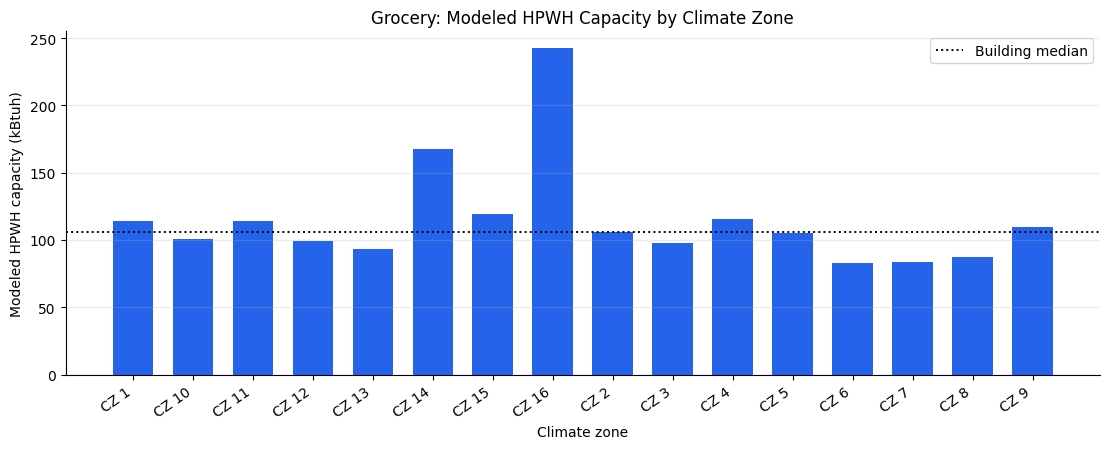

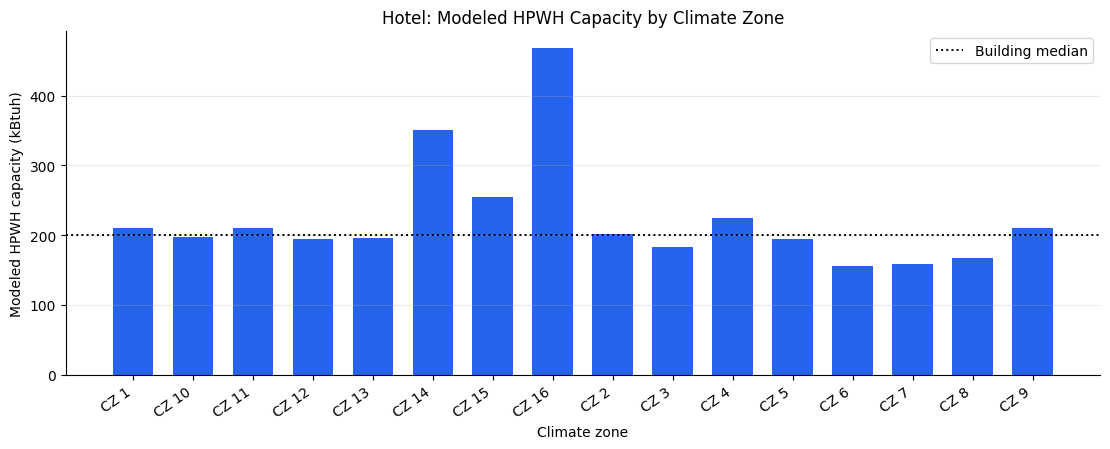

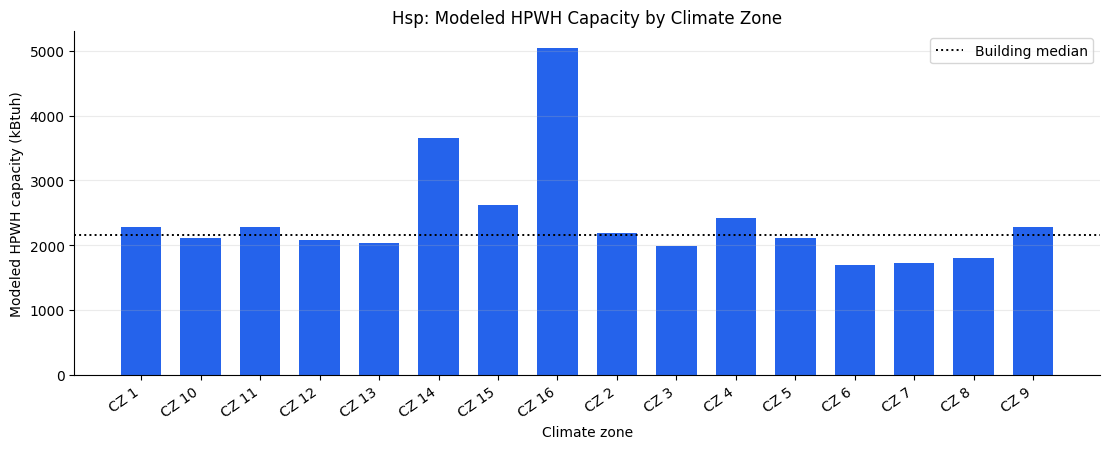

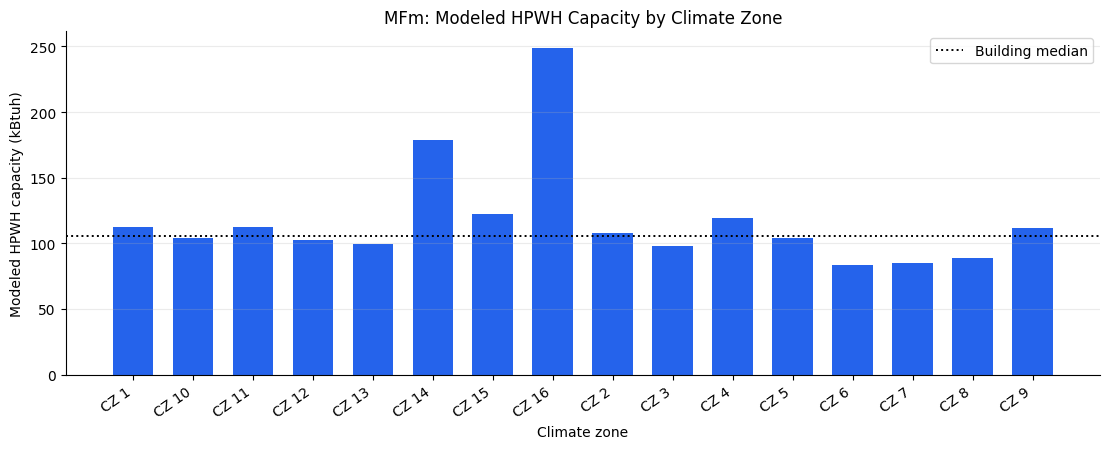

,Building,CZ,Baseline,modeled_annual_therms,hp_cops_in_model,building_baseline_median_therms,therms_minus_building_baseline_median,therms_pct_diff_vs_building_baseline_median
0,Grocery,1,CODE,3839.304019,"3, 4.3",3326.149816,513.154203,0.154279
1,Grocery,1,EXISTING,4123.543271,"3, 4.3",3572.101828,551.441442,0.154375
2,Grocery,10,CODE,3143.127338,"3, 4.3",3326.149816,-183.022478,-0.055025
3,Grocery,10,EXISTING,3375.512933,"3, 4.3",3572.101828,-196.588896,-0.055035
4,Grocery,11,CODE,3839.304019,"3, 4.3",3326.149816,513.154203,0.154279
...,...,...,...,...,...,...,...,...
123,MFm,7,EXISTING,2414.641401,3,2485.759432,-71.118031,-0.028610
124,MFm,8,CODE,2356.535553,3,2480.023239,-123.487686,-0.049793
125,MFm,8,EXISTING,2362.284088,3,2485.759432,-123.475345,-0.049673
126,MFm,9,CODE,2374.572844,3,2480.023239,-105.450395,-0.042520


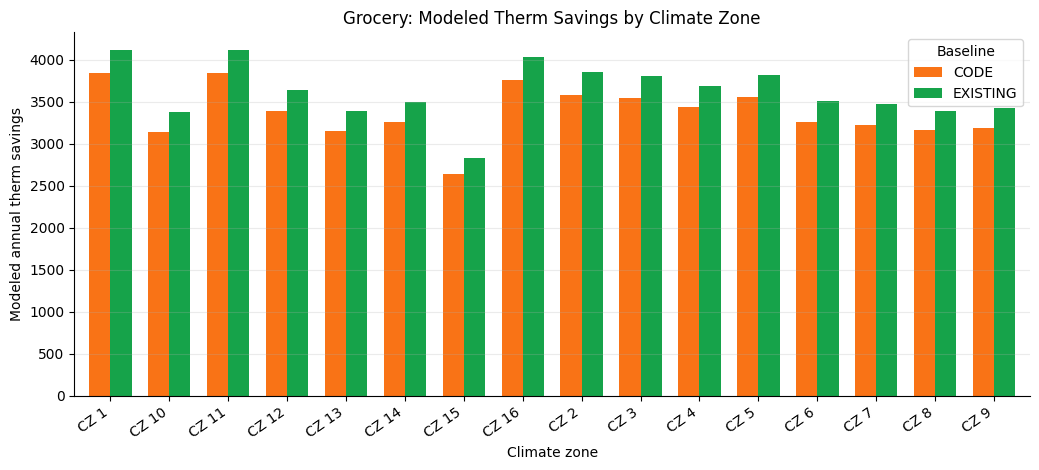

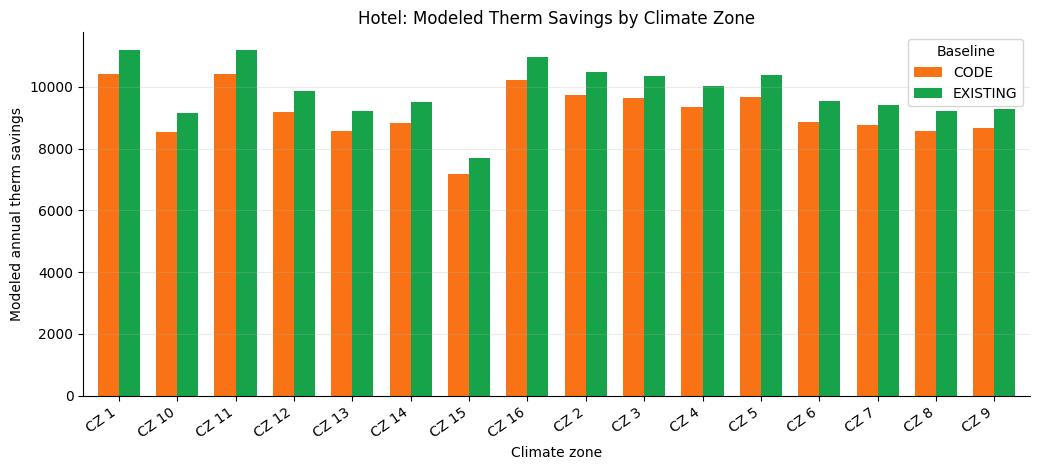

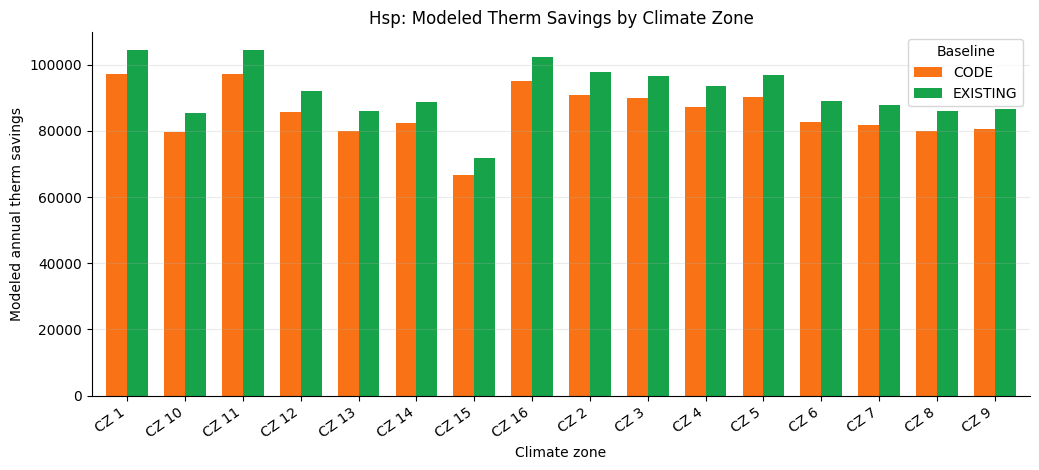

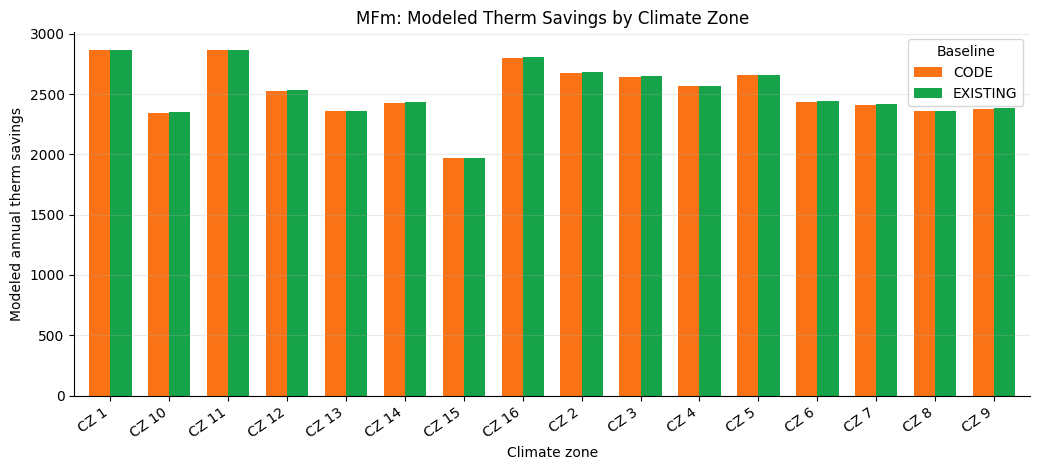

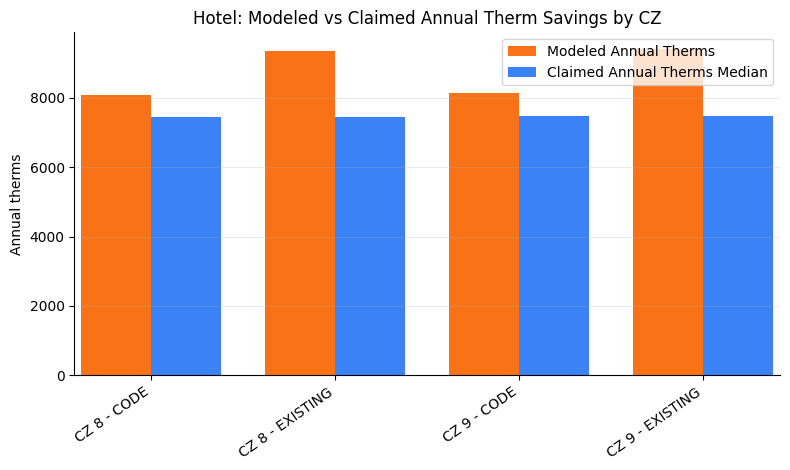

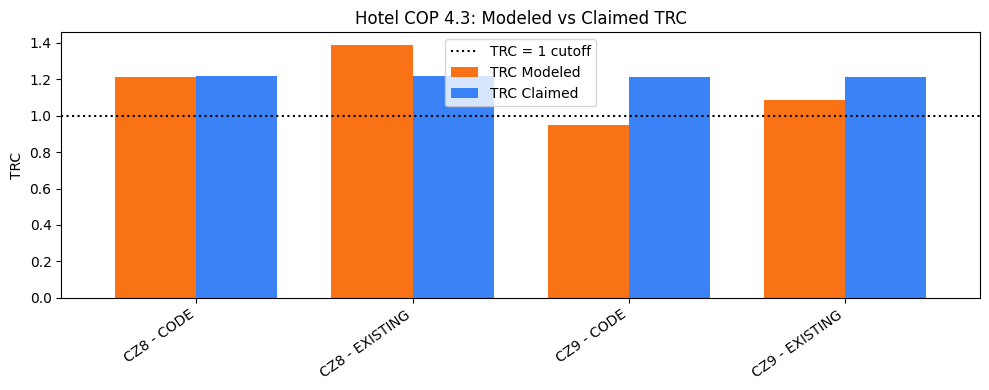

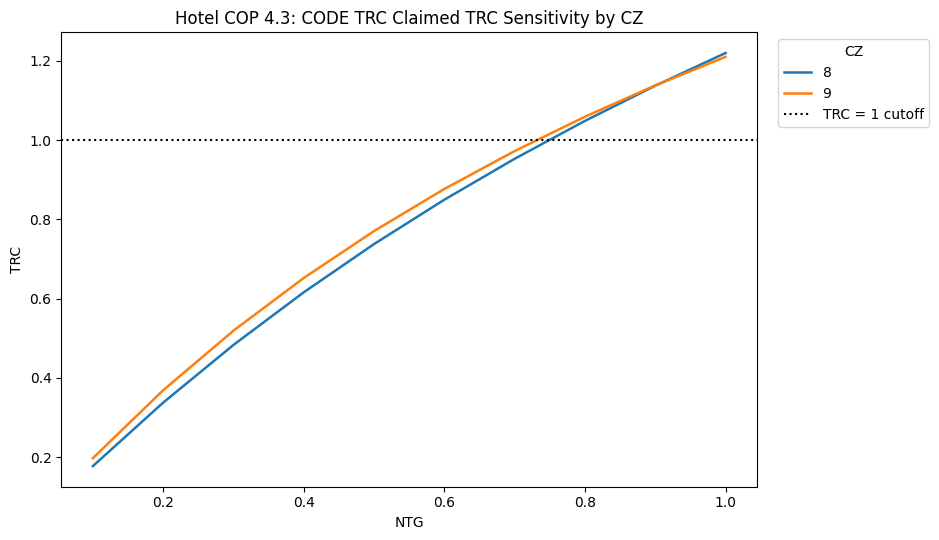

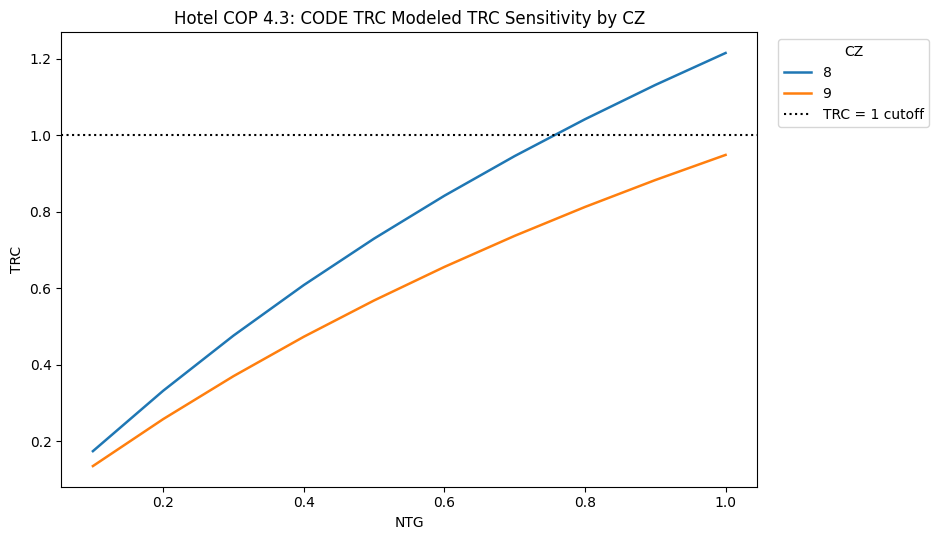

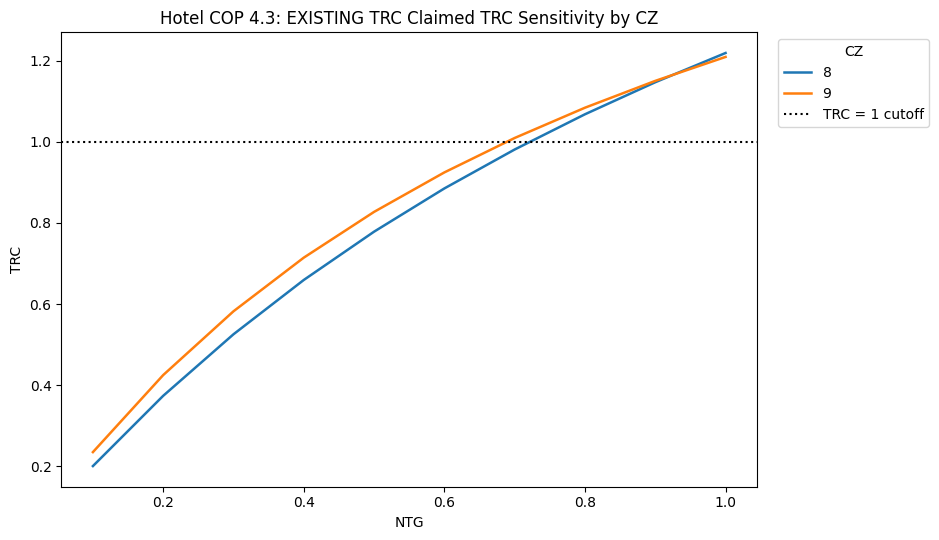

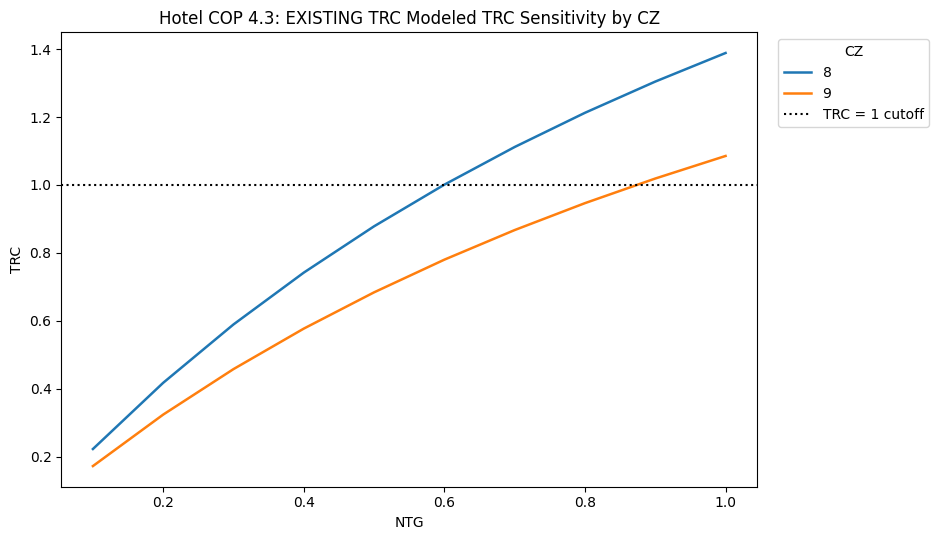

In [162]:
import contextlib
import io
import sys

ANALYSIS_CELL_INDICES = [3, 5, 7, 9, 11, 13, 15]


def _scenario_value(scenario, lower_name, selected_name, default=None):
    return scenario.get(lower_name, scenario.get(selected_name, default))


def _set_selected_scenario(scenario):
    global SELECTED_CLIMATE_ZONE, SELECTED_BUILDING_TYPE, SELECTED_BASELINE_TYPE
    global SELECTED_HP_COP, SELECTED_MODELED_HP_HEATING_CAPACITY_KBTUH, SELECTED_MODELED_UNIT_COUNT
    global SELECTED_DISCOUNT_RATE, SELECTED_CLAIMS_YEAR
    global SELECTED_OFFERING_TYPE, SELECTED_TRC_COST_MATCH_COUNT

    SELECTED_CLIMATE_ZONE = str(_scenario_value(scenario, "climate_zone", "SELECTED_CLIMATE_ZONE", SELECTED_CLIMATE_ZONE))
    SELECTED_BUILDING_TYPE = str(_scenario_value(scenario, "building_type", "SELECTED_BUILDING_TYPE", SELECTED_BUILDING_TYPE))
    SELECTED_BASELINE_TYPE = str(_scenario_value(scenario, "baseline_type", "SELECTED_BASELINE_TYPE", SELECTED_BASELINE_TYPE))
    SELECTED_HP_COP = float(_scenario_value(scenario, "hp_cop", "SELECTED_HP_COP", DEFAULT_SCENARIO_OPTIONS["hp_cop"]))
    SELECTED_MODELED_HP_HEATING_CAPACITY_KBTUH = float(_scenario_value(
        scenario,
        "modeled_hp_heating_capacity_kbtuh",
        "SELECTED_MODELED_HP_HEATING_CAPACITY_KBTUH",
        get_model_es_modeled_capacity_kbtuh(SELECTED_CLIMATE_ZONE, SELECTED_BUILDING_TYPE, SELECTED_HP_COP),
    ))
    SELECTED_MODELED_UNIT_COUNT = float(_scenario_value(
        scenario,
        "modeled_unit_count",
        "SELECTED_MODELED_UNIT_COUNT",
        1.0,
    ))
    SELECTED_DISCOUNT_RATE = float(_scenario_value(scenario, "discount_rate", "SELECTED_DISCOUNT_RATE", DEFAULT_SCENARIO_OPTIONS["discount_rate"]))
    SELECTED_CLAIMS_YEAR = str(_scenario_value(scenario, "claims_year", "SELECTED_CLAIMS_YEAR", DEFAULT_SCENARIO_OPTIONS["claims_year"]))
    SELECTED_OFFERING_TYPE = str(_scenario_value(scenario, "offering_type", "SELECTED_OFFERING_TYPE", DEFAULT_SCENARIO_OPTIONS["offering_type"]))
    SELECTED_TRC_COST_MATCH_COUNT = int(_scenario_value(
        scenario,
        "trc_cost_match_count",
        "SELECTED_TRC_COST_MATCH_COUNT",
        DEFAULT_SCENARIO_OPTIONS["trc_cost_match_count"],
    ))


def _load_analysis_cell_sources():
    return ["".join(__notebook_cell__["source"]) for __notebook_cell__ in [globals().get("_CURRENT_NOTEBOOK_CELLS", [])[i] for i in ANALYSIS_CELL_INDICES]] if globals().get("_CURRENT_NOTEBOOK_CELLS") else ["".join(json.loads(Path("Avoided Costs.ipynb").read_text(encoding="utf-8"))["cells"][i]["source"]) for i in ANALYSIS_CELL_INDICES]


def _collect_scenario_summary(run_id, status="ok", error=None):
    selected_match = globals().get("selected_trc_cost_match", {})
    if hasattr(selected_match, "to_dict"):
        selected_match = selected_match.to_dict()
    claims_filtered_data = globals().get("claims_filtered")
    claims_therm_compare_data = globals().get("claims_therm_compare")
    claim_unit_therm_data = claims_therm_compare_data
    if claim_unit_therm_data is None or claim_unit_therm_data.empty:
        claim_unit_therm_data = globals().get("claim_trc_scenarios")
    if claim_unit_therm_data is not None and not claim_unit_therm_data.empty:
        claim_unit_therm_1st_baseline = pd.to_numeric(
            claim_unit_therm_data.get("claims_therms_per_kbtuh_1st_baseline"),
            errors="coerce",
        ).dropna().median()
        claim_unit_therm_2nd_baseline = pd.to_numeric(
            claim_unit_therm_data.get("claims_therms_per_kbtuh_2nd_baseline"),
            errors="coerce",
        ).dropna().median()
        claim_unit_therm_lookup_source = ", ".join(
            sorted(claim_unit_therm_data.get("claims_therms_per_kbtuh_lookup_source", pd.Series(dtype="object")).dropna().astype(str).unique())
        )
    else:
        claim_unit_therm_1st_baseline = globals().get("selected_swwh_unit_therm_1st_baseline")
        claim_unit_therm_2nd_baseline = globals().get("selected_swwh_unit_therm_2nd_baseline")
        claim_unit_therm_lookup_source = "SWWH028 selected scenario rows fallback"
    claimed_trc_raw_median = pd.to_numeric(claims_filtered_data["TRC"], errors="coerce").median() if claims_filtered_data is not None and "TRC" in claims_filtered_data else np.nan
    claimed_trc_cost_median = pd.to_numeric(claims_filtered_data["TRC Cost"], errors="coerce").median() if claims_filtered_data is not None and "TRC Cost" in claims_filtered_data else np.nan
    claimed_benefits_median = pd.to_numeric(claims_filtered_data["Benefits"], errors="coerce").median() if claims_filtered_data is not None and "Benefits" in claims_filtered_data else np.nan
    claimed_total_system_benefit_median = (
        pd.to_numeric(claims_filtered_data["Total System Benefit"], errors="coerce").median()
        if claims_filtered_data is not None and "Total System Benefit" in claims_filtered_data
        else claimed_benefits_median
    )
    claimed_annual_therms = (
        pd.to_numeric(claims_filtered_data["First Year Gross Therm"], errors="coerce").dropna()
        if claims_filtered_data is not None and "First Year Gross Therm" in claims_filtered_data
        else pd.Series(dtype="float64")
    )
    claimed_annual_therms_count = int(claimed_annual_therms.count())
    claimed_annual_therms_median = claimed_annual_therms.median() if claimed_annual_therms_count else np.nan
    claimed_annual_therms_mean = claimed_annual_therms.mean() if claimed_annual_therms_count else np.nan
    claimed_annual_therms_sum = claimed_annual_therms.sum() if claimed_annual_therms_count else np.nan
    modeled_annual_therms = globals().get("modeled_total_therms", np.nan)
    modeled_minus_claimed_annual_therms_median = modeled_annual_therms - claimed_annual_therms_median
    modeled_pct_diff_vs_claimed_annual_therms_median = (
        modeled_minus_claimed_annual_therms_median / claimed_annual_therms_median
        if pd.notna(claimed_annual_therms_median) and claimed_annual_therms_median != 0
        else np.nan
    )
    swwh_measure_cost_dual_component = globals().get("selected_swwh_dual_baseline_measure_cost_per_kbtuh", np.nan) * globals().get("modeled_capacity_kbtuh", np.nan)
    claimed_other_trc_cost_component = claimed_trc_cost_median - swwh_measure_cost_dual_component
    claimed_trc = claimed_trc_raw_median
    claimed_trc_source = f"Median claimed TRC from claims rows selected by: {globals().get('claims_cost_match_basis')}; claims are assumed to already include AR dual-baseline costs"
    claimed_therms_per_kbtuh = globals().get("selected_swwh_dual_baseline_therm_per_kbtuh", np.nan)
    swwh028_filtered_data = globals().get("swwh028_filtered")
    if swwh028_filtered_data is not None and not swwh028_filtered_data.empty:
        swwh_meas_app_types = ", ".join(sorted(swwh028_filtered_data["MeasAppType"].dropna().astype(str).unique()))
        swwh_measure_codes = ", ".join(sorted(swwh028_filtered_data["MeasCode"].dropna().astype(str).unique()))
    else:
        swwh_meas_app_types = None
        swwh_measure_codes = None

    return {
        "run_id": run_id,
        "status": status,
        "error": error,
        "climate_zone": SELECTED_CLIMATE_ZONE,
        "building_type": SELECTED_BUILDING_TYPE,
        "baseline_type": SELECTED_BASELINE_TYPE,
        "measure_application_type": SELECTED_MEASURE_APPLICATION_TYPE,
        "hp_cop": SELECTED_HP_COP,
        "modeled_unit_count": SELECTED_MODELED_UNIT_COUNT,
        "modeled_capacity_kbtuh": globals().get("modeled_capacity_kbtuh"),
        "modeled_total_therms": modeled_annual_therms,
        "claimed_annual_therms_count": claimed_annual_therms_count,
        "claimed_annual_therms_median": claimed_annual_therms_median,
        "claimed_annual_therms_mean": claimed_annual_therms_mean,
        "claimed_annual_therms_sum": claimed_annual_therms_sum,
        "modeled_minus_claimed_annual_therms_median": modeled_minus_claimed_annual_therms_median,
        "modeled_pct_diff_vs_claimed_annual_therms_median": modeled_pct_diff_vs_claimed_annual_therms_median,
        "modeled_therms_per_kbtuh": globals().get("modeled_therms_per_kbtuh"),
        "claimed_therms_per_kbtuh": claimed_therms_per_kbtuh,
        "claimed_therms_per_kbtuh_1st_baseline": claim_unit_therm_1st_baseline,
        "claimed_therms_per_kbtuh_2nd_baseline": claim_unit_therm_2nd_baseline,
        "claimed_therms_per_kbtuh_lookup_source": claim_unit_therm_lookup_source,
        "swwh028_meas_app_type_filter": globals().get("swwh_measure_application_type_filter"),
        "swwh028_selected_meas_app_types": swwh_meas_app_types,
        "swwh028_selected_measure_codes": swwh_measure_codes,
        "swwh028_claim_measure_keys": globals().get("selected_swwh_measure_codes_for_claims"),
        "swwh028_unit_therm_match_basis": globals().get("swwh028_unit_therm_match_basis"),
        "swwh028_unit_therm_rows": len(swwh028_filtered_data) if swwh028_filtered_data is not None else 0,
        "modeled_total_kwh": globals().get("modeled_total_kwh"),
        "claims_filtered_rows": len(globals().get("claims_filtered", [])),
        "claims_cost_match_basis": globals().get("claims_cost_match_basis"),
        "claims_therm_compare_rows": len(globals().get("claims_therm_compare", [])),
        "selected_hpwh_workbook": getattr(globals().get("selected_hpwh_workbook"), "name", None),
        "code_hpwh_workbook": getattr(globals().get("code_hpwh_workbook"), "name", None),
        "model_es_baseline_source": globals().get("selected_model_es_metadata", {}).get("baseline_source"),
        "model_es_run_count": globals().get("selected_model_es_metadata", {}).get("model_run_count"),
        "model_es_files": globals().get("selected_model_es_metadata", {}).get("model_files"),
        "selected_trc_cost_scenario": selected_match.get("scenario"),
        "selected_trc_cost": selected_match.get("claim_derived_trc_cost"),
        "selected_trc_cost_per_kbtuh": selected_match.get("trc_cost_per_kbtuh"),
        "swwh_unit_therm_1st_baseline": globals().get("selected_swwh_unit_therm_1st_baseline"),
        "swwh_unit_therm_2nd_baseline": globals().get("selected_swwh_unit_therm_2nd_baseline"),
        "swwh_rul_years": globals().get("selected_swwh_rul_years"),
        "swwh_dual_baseline_basis": globals().get("selected_swwh_dual_baseline_basis"),
        "swwh_measure_cost_per_kbtuh": globals().get("selected_swwh_dual_baseline_measure_cost_per_kbtuh"),
        "swwh_measure_cost_component": swwh_measure_cost_dual_component,
        "modeled_other_trc_cost_component": selected_match.get("other_trc_cost_component"),
        "claimed_trc_cost_median": claimed_trc_cost_median,
        "claimed_benefits_median": claimed_benefits_median,
        "claimed_total_system_benefit_median": claimed_total_system_benefit_median,
        "claimed_raw_trc_median": claimed_trc_raw_median,
        "claimed_other_trc_cost_component": claimed_other_trc_cost_component,
        "modeled_total_system_benefit_eul_undiscounted": globals().get("modeled_total_system_benefit_eul_undiscounted"),
        "modeled_total_system_benefit_eul": globals().get("modeled_total_system_benefit_eul"),
        "modeled_trc": selected_match.get("modeled_trc"),
        "claimed_trc": claimed_trc,
        "claimed_trc_source": claimed_trc_source,
    }


def run_scenario_batch(scenarios=SCENARIO_RUNS, quiet=True):
    analysis_cell_sources = _load_analysis_cell_sources()
    summaries = []
    trc_scenario_tables = []
    original_display = globals().get("display")

    for run_index, scenario in enumerate(scenarios, start=1):
        run_id = f"CZ{_scenario_value(scenario, 'climate_zone', 'SELECTED_CLIMATE_ZONE')}_{_scenario_value(scenario, 'building_type', 'SELECTED_BUILDING_TYPE')}_{_scenario_value(scenario, 'baseline_type', 'SELECTED_BASELINE_TYPE')}"
        _set_selected_scenario(scenario)

        try:
            if quiet:
                globals()["display"] = lambda *args, **kwargs: None
                with contextlib.redirect_stdout(io.StringIO()):
                    for source in analysis_cell_sources:
                        exec(source, globals())
            else:
                print(f"Running {run_id}")
                for source in analysis_cell_sources:
                    exec(source, globals())

            summaries.append(_collect_scenario_summary(run_id))

            scenario_trc = globals().get("trc_cost_scenarios")
            if scenario_trc is not None:
                scenario_trc = scenario_trc.copy()
                scenario_trc.insert(0, "run_id", run_id)
                scenario_trc.insert(1, "climate_zone", SELECTED_CLIMATE_ZONE)
                scenario_trc.insert(2, "building_type", SELECTED_BUILDING_TYPE)
                scenario_trc.insert(3, "baseline_type", SELECTED_BASELINE_TYPE)
                trc_scenario_tables.append(scenario_trc)
        except Exception as exc:
            summaries.append(_collect_scenario_summary(run_id, status="error", error=str(exc)))
        finally:
            if original_display is not None:
                globals()["display"] = original_display

    summary_df = pd.DataFrame(summaries)
    trc_scenarios_df = pd.concat(trc_scenario_tables, ignore_index=True, sort=False) if trc_scenario_tables else pd.DataFrame()
    return summary_df, trc_scenarios_df


scenario_results, scenario_trc_cost_scenarios = run_scenario_batch(SCENARIO_RUNS)
display(scenario_results)
display(scenario_trc_cost_scenarios.head(int(SELECTED_TRC_COST_MATCH_COUNT) * max(len(SCENARIO_RUNS), 1)))

summary_output = scenario_results[scenario_results["status"].eq("ok")].rename(
    columns={
        "building_type": "Building",
        "hp_cop": "HP COP",
        "climate_zone": "CZ",
        "baseline_type": "Baseline [Code, Existing]",
        "measure_application_type": "MeasAppType",
        "swwh028_selected_meas_app_types": "SWWH028 MeasAppType",
        "swwh028_selected_measure_codes": "SWWH028 MeasCode",
        "swwh028_unit_therm_match_basis": "SWWH028 Match Basis",
        "swwh028_claim_measure_keys": "SWWH028 Claim Tech ID Keys",
        "code_hpwh_workbook": "Model Runs ES Folder",
        "model_es_baseline_source": "Model Runs ES Baseline Source",
        "model_es_run_count": "Model Runs ES Run Count",
        "model_es_files": "Model Runs ES Files",
        "modeled_total_therms": "Modeled Annual Therms",
        "claimed_annual_therms_count": "Claimed Annual Therm Rows",
        "claimed_annual_therms_median": "Claimed Annual Therms Median",
        "claimed_annual_therms_mean": "Claimed Annual Therms Mean",
        "claimed_annual_therms_sum": "Claimed Annual Therms Sum",
        "modeled_minus_claimed_annual_therms_median": "Modeled - Claimed Annual Therms Median",
        "modeled_pct_diff_vs_claimed_annual_therms_median": "Modeled % Diff vs Claimed Annual Therms Median",
        "modeled_therms_per_kbtuh": "therm/kbtuh Modeled",
        "claimed_therms_per_kbtuh": "therm/kbtuh Claimed",
        "modeled_trc": "TRC Modeled",
        "claimed_trc": "TRC Claimed",
        "claimed_trc_source": "TRC Claimed Basis",
        "swwh_unit_therm_1st_baseline": "SWWH028 UnitTherm1stBaseline",
        "swwh_unit_therm_2nd_baseline": "SWWH028 UnitTherm2ndBaseline",
        "swwh_rul_years": "RUL Years",
        "swwh_dual_baseline_basis": "Dual Baseline Basis",
        "swwh_measure_cost_per_kbtuh": "SWWH028 Measure Cost/kBtuh",
        "swwh_measure_cost_component": "SWWH028 Measure Cost Component",
        "modeled_total_system_benefit_eul": "Modeled Benefits PV",
        "claimed_total_system_benefit_median": "Claimed Total System Benefit Median",
        "selected_trc_cost": "Modeled TRC Cost",
        "modeled_other_trc_cost_component": "Modeled Other TRC Cost Component",
        "claimed_trc_cost_median": "Claimed TRC Cost Median",
        "claimed_raw_trc_median": "Claimed Raw TRC Median",
        "claimed_benefits_median": "Claimed Benefits Median",
        "claimed_other_trc_cost_component": "Claimed Other TRC Cost Component",
    }
)
summary_display_columns = [
    "Building",
    "HP COP",
    "CZ",
    "Baseline [Code, Existing]",
    "MeasAppType",
    "SWWH028 MeasAppType",
    "SWWH028 MeasCode",
    "SWWH028 Match Basis",
    "SWWH028 Claim Tech ID Keys",
    "Model Runs ES Baseline Source",
    "Model Runs ES Run Count",
    "Modeled Annual Therms",
    "Claimed Annual Therms Median",
    "Modeled - Claimed Annual Therms Median",
    "Modeled % Diff vs Claimed Annual Therms Median",
    "therm/kbtuh Modeled",
    "therm/kbtuh Claimed",
    "TRC Modeled",
    "TRC Claimed",
    "Modeled TRC Cost",
    "Modeled Benefits PV",
    "Claimed Total System Benefit Median",
    "TRC Claimed Basis",
]
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
summary_numeric_columns = ["HP COP", "Model Runs ES Run Count", "Modeled Annual Therms", "Claimed Annual Therm Rows", "Claimed Annual Therms Median", "Claimed Annual Therms Mean", "Claimed Annual Therms Sum", "Modeled - Claimed Annual Therms Median", "Modeled % Diff vs Claimed Annual Therms Median", "therm/kbtuh Modeled", "therm/kbtuh Claimed", "TRC Modeled", "TRC Claimed", "RUL Years", "SWWH028 Measure Cost/kBtuh", "SWWH028 Measure Cost Component", "Modeled Benefits PV", "Claimed Total System Benefit Median", "Modeled TRC Cost", "Modeled Other TRC Cost Component", "Claimed TRC Cost Median", "Claimed Raw TRC Median", "Claimed Benefits Median", "Claimed Other TRC Cost Component"]
summary_output_for_csv = summary_output.copy()
summary_output_for_csv = summary_output_for_csv.drop(
    columns=[
        "claimed_therms_per_kbtuh_1st_baseline",
        "claimed_therms_per_kbtuh_2nd_baseline",
        "claimed_therms_per_kbtuh_lookup_source",
        "SWWH028 UnitTherm1stBaseline",
        "SWWH028 UnitTherm2ndBaseline",
    ],
    errors="ignore",
)
summary_numeric_columns = [col for col in summary_numeric_columns if col in summary_output_for_csv.columns]
summary_output_for_csv[summary_numeric_columns] = summary_output_for_csv[summary_numeric_columns].apply(pd.to_numeric, errors="coerce")
summary_output_for_csv.to_csv(OUTPUT_DIR / "summary_output.csv", index=False, float_format="%.6f")
display(summary_output[summary_display_columns])

trc_chart_data = summary_output[["CZ", "Building", "HP COP", "Baseline [Code, Existing]", "TRC Modeled", "TRC Claimed"]].copy()
trc_chart_data = trc_chart_data.rename(columns={"Baseline [Code, Existing]": "Baseline"})
trc_chart_data[["TRC Modeled", "TRC Claimed"]] = trc_chart_data[["TRC Modeled", "TRC Claimed"]].apply(pd.to_numeric, errors="coerce")
trc_chart_data.to_csv(OUTPUT_DIR / "trc_summary_comparison.csv", index=False, float_format="%.6f")
display(trc_chart_data)

tsb_chart_data = summary_output[["CZ", "Building", "HP COP", "Baseline [Code, Existing]", "Modeled Benefits PV", "Claimed Total System Benefit Median"]].copy()
tsb_chart_data = tsb_chart_data.rename(columns={"Baseline [Code, Existing]": "Baseline"})
tsb_chart_data[["Modeled Benefits PV", "Claimed Total System Benefit Median"]] = tsb_chart_data[["Modeled Benefits PV", "Claimed Total System Benefit Median"]].apply(pd.to_numeric, errors="coerce")
tsb_chart_data.to_csv(OUTPUT_DIR / "tsb_summary_comparison.csv", index=False, float_format="%.6f")
display(tsb_chart_data)

therm_chart_data = summary_output[["CZ", "Building", "HP COP", "Baseline [Code, Existing]", "Modeled Annual Therms", "Claimed Annual Therms Median", "therm/kbtuh Modeled", "therm/kbtuh Claimed"]].copy()
therm_chart_data = therm_chart_data.rename(columns={"Baseline [Code, Existing]": "Baseline"})
therm_numeric_columns = ["Modeled Annual Therms", "Claimed Annual Therms Median", "therm/kbtuh Modeled", "therm/kbtuh Claimed"]
therm_chart_data[therm_numeric_columns] = therm_chart_data[therm_numeric_columns].apply(pd.to_numeric, errors="coerce")
therm_chart_data.to_csv(OUTPUT_DIR / "therm_summary_comparison.csv", index=False, float_format="%.6f")
display(therm_chart_data)

def _building_slug(building):
    return re.sub(r"[^A-Za-z0-9]+", "_", str(building)).strip("_").lower()


def _cop_slug(hp_cop):
    return f"cop_{str(float(hp_cop)).replace('.', '_')}"

capacity_sensitivity = MODEL_ES_MODELED_CAPACITY[["building_type", "climate_zone", "hp_cop", "modeled_capacity_kbtuh"]].copy()
capacity_sensitivity = capacity_sensitivity.rename(columns={"building_type": "Building", "climate_zone": "CZ", "hp_cop": "HP COP"})
capacity_sensitivity["modeled_capacity_kbtuh"] = pd.to_numeric(capacity_sensitivity["modeled_capacity_kbtuh"], errors="coerce")
capacity_sensitivity = (
    capacity_sensitivity.dropna(subset=["modeled_capacity_kbtuh"])
    .groupby(["Building", "CZ"], as_index=False)
    .agg(
        modeled_capacity_kbtuh=("modeled_capacity_kbtuh", "median"),
        hp_cops_in_model=("HP COP", lambda values: ", ".join(f"{value:g}" for value in sorted(set(values)))),
    )
    .sort_values(["Building", "CZ"])
)
capacity_sensitivity["building_median_capacity_kbtuh"] = capacity_sensitivity.groupby("Building")["modeled_capacity_kbtuh"].transform("median")
capacity_sensitivity["capacity_minus_building_median_kbtuh"] = capacity_sensitivity["modeled_capacity_kbtuh"] - capacity_sensitivity["building_median_capacity_kbtuh"]
capacity_sensitivity["capacity_pct_diff_vs_building_median"] = np.where(
    capacity_sensitivity["building_median_capacity_kbtuh"] != 0,
    capacity_sensitivity["capacity_minus_building_median_kbtuh"] / capacity_sensitivity["building_median_capacity_kbtuh"],
    np.nan,
)
capacity_sensitivity.to_csv(OUTPUT_DIR / "capacity_sensitivity_by_building_cz.csv", index=False, float_format="%.6f")
# display(capacity_sensitivity)

# Sensitivity-analysis plot output suppressed.
# for building, building_data in capacity_sensitivity.groupby("Building", sort=True):
#     building_data = building_data.sort_values("CZ").copy()
#     x_positions = np.arange(len(building_data))
#     fig_width = max(8, min(15, 0.45 * len(building_data) + 4))
#     fig, ax = plt.subplots(figsize=(fig_width, 4.6))
#     ax.bar(x_positions, building_data["modeled_capacity_kbtuh"], color="#2563eb", width=0.68)
#     ax.axhline(building_data["building_median_capacity_kbtuh"].iloc[0], color="black", linestyle=":", linewidth=1.4, label="Building median")
#     ax.set_xlabel("Climate zone")
#     ax.set_ylabel("Modeled HPWH capacity (kBtuh)")
#     ax.set_title(f"{building}: Modeled HPWH Capacity by Climate Zone")
#     ax.set_xticks(x_positions)
#     ax.set_xticklabels("CZ " + building_data["CZ"].astype(str), rotation=35, ha="right")
#     ax.grid(axis="y", alpha=0.25)
#     ax.spines[["top", "right"]].set_visible(False)
#     ax.legend(title="")
#     plt.tight_layout()
#     plt.savefig(OUTPUT_DIR / f"capacity_sensitivity_{_building_slug(building)}.png", dpi=200, bbox_inches="tight")
#     plt.show()
#     plt.close()

therm_sensitivity_rows = []
for row in MODEL_ES_MODELED_CAPACITY.itertuples(index=False):
    for baseline in ["CODE", "EXISTING"]:
        try:
            hourly, _metadata = _get_model_es_hourly_per_kbtuh(row.climate_zone, row.building_type, baseline, row.hp_cop)
        except Exception:
            continue
        therm_sensitivity_rows.append(
            {
                "Building": row.building_type,
                "CZ": row.climate_zone,
                "HP COP": row.hp_cop,
                "Baseline": baseline,
                "modeled_annual_therms": hourly["gas_therms_per_kbtuh"].sum() * row.modeled_capacity_kbtuh,
            }
        )
therm_sensitivity = pd.DataFrame(therm_sensitivity_rows)
if not therm_sensitivity.empty:
    therm_sensitivity = (
        therm_sensitivity.groupby(["Building", "CZ", "Baseline"], as_index=False)
        .agg(
            modeled_annual_therms=("modeled_annual_therms", "median"),
            hp_cops_in_model=("HP COP", lambda values: ", ".join(f"{value:g}" for value in sorted(set(values)))),
        )
        .sort_values(["Building", "CZ", "Baseline"])
    )
    therm_sensitivity["building_baseline_median_therms"] = therm_sensitivity.groupby(["Building", "Baseline"])["modeled_annual_therms"].transform("median")
    therm_sensitivity["therms_minus_building_baseline_median"] = therm_sensitivity["modeled_annual_therms"] - therm_sensitivity["building_baseline_median_therms"]
    therm_sensitivity["therms_pct_diff_vs_building_baseline_median"] = np.where(
        therm_sensitivity["building_baseline_median_therms"] != 0,
        therm_sensitivity["therms_minus_building_baseline_median"] / therm_sensitivity["building_baseline_median_therms"],
        np.nan,
    )
else:
    therm_sensitivity = pd.DataFrame(columns=["Building", "CZ", "Baseline", "modeled_annual_therms", "hp_cops_in_model", "building_baseline_median_therms", "therms_minus_building_baseline_median", "therms_pct_diff_vs_building_baseline_median"])
therm_sensitivity.to_csv(OUTPUT_DIR / "therm_savings_sensitivity_by_building_cz.csv", index=False, float_format="%.6f")
# display(therm_sensitivity)

# Sensitivity-analysis plot output suppressed.
# for building, building_data in therm_sensitivity.groupby("Building", sort=True):
#     therm_pivot = building_data.pivot_table(index="CZ", columns="Baseline", values="modeled_annual_therms")
#     if therm_pivot.empty:
#         continue
#     therm_pivot = therm_pivot.sort_index()
#     ax = therm_pivot.plot(kind="bar", figsize=(10.5, 4.8), width=0.72, color=["#f97316", "#16a34a"])
#     ax.set_xlabel("Climate zone")
#     ax.set_ylabel("Modeled annual therm savings")
#     ax.set_title(f"{building}: Modeled Therm Savings by Climate Zone")
#     ax.set_xticklabels([f"CZ {value}" for value in therm_pivot.index], rotation=35, ha="right")
#     ax.grid(axis="y", alpha=0.25)
#     ax.spines[["top", "right"]].set_visible(False)
#     ax.legend(title="Baseline")
#     plt.tight_layout()
#     plt.savefig(OUTPUT_DIR / f"therm_savings_sensitivity_{_building_slug(building)}.png", dpi=200, bbox_inches="tight")
#     plt.show()
#     plt.close()

for building, building_data in therm_chart_data.groupby("Building", sort=True):
    building_data = building_data.dropna(subset=["Modeled Annual Therms", "Claimed Annual Therms Median"]).copy()
    building_data = building_data.groupby(["CZ", "Building", "Baseline"], as_index=False).agg(
        **{
            "Modeled Annual Therms": ("Modeled Annual Therms", "median"),
            "Claimed Annual Therms Median": ("Claimed Annual Therms Median", "median"),
        }
    ).sort_values(["CZ", "Baseline"])
    if building_data.empty:
        continue
    building_data["Scenario"] = "CZ " + building_data["CZ"].astype(str) + " - " + building_data["Baseline"].astype(str)
    x_positions = np.arange(len(building_data))
    bar_width = 0.38
    fig_width = max(8, min(16, 0.62 * len(building_data) + 4))
    fig, ax = plt.subplots(figsize=(fig_width, 4.8))
    ax.bar(x_positions - bar_width / 2, building_data["Modeled Annual Therms"], width=bar_width, color="#f97316", label="Modeled Annual Therms")
    ax.bar(x_positions + bar_width / 2, building_data["Claimed Annual Therms Median"], width=bar_width, color="#3b82f6", label="Claimed Annual Therms Median")
    ax.set_xlabel("")
    ax.set_ylabel("Annual therms")
    ax.set_title(f"{building}: Modeled vs Claimed Annual Therm Savings by CZ")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(building_data["Scenario"])
    ax.margins(x=0.01)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"therm_summary_comparison_{_building_slug(building)}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

for (building, hp_cop), building_data in tsb_chart_data.groupby(["Building", "HP COP"], sort=True):
    building_data = building_data.sort_values(["CZ", "Baseline"]).copy()
    building_data["Scenario"] = "CZ" + building_data["CZ"].astype(str) + " - " + building_data["Baseline"].astype(str)
    tsb_plot_data = building_data.set_index("Scenario")[["Modeled Benefits PV", "Claimed Total System Benefit Median"]]
    tsb_plot_data = tsb_plot_data.dropna(how="any")
    if tsb_plot_data.empty:
        continue
    ax = tsb_plot_data.plot(kind="bar", figsize=(10, 4.6), width=0.75, color=["#f97316", "#3b82f6"])
    ax.set_xlabel("")
    ax.set_ylabel("Total system benefit ($ PV)")
    ax.set_title(f"{building} COP {hp_cop:g}: Modeled vs Claimed TSB")
    ax.legend(title="")
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"tsb_summary_comparison_{_building_slug(building)}_{_cop_slug(hp_cop)}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

for (building, hp_cop), building_data in trc_chart_data.groupby(["Building", "HP COP"], sort=True):
    building_data = building_data.sort_values(["CZ", "Baseline"]).copy()
    building_data["Scenario"] = "CZ" + building_data["CZ"].astype(str) + " - " + building_data["Baseline"].astype(str)
    trc_plot_data = building_data.set_index("Scenario")[["TRC Modeled", "TRC Claimed"]]
    trc_plot_data = trc_plot_data.dropna(how="any")
    if trc_plot_data.empty:
        continue
    ax = trc_plot_data.plot(kind="bar", figsize=(10, 4), width=0.75, color=["#f97316", "#3b82f6"])
    ax.set_xlabel("")
    ax.set_ylabel("TRC")
    ax.set_title(f"{building} COP {hp_cop:g}: Modeled vs Claimed TRC")
    ax.axhline(1, color="black", linestyle=":", linewidth=1.5, label="TRC = 1 cutoff")
    ax.legend(title="")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"trc_summary_comparison_{_building_slug(building)}_{_cop_slug(hp_cop)}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

BASE_NTG = 1.0
NTG_SENSITIVITY_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 2)

ntg_modeled_base = summary_output[[
    "Building",
    "HP COP",
    "CZ",
    "Baseline [Code, Existing]",
    "TRC Modeled",
    "Modeled Benefits PV",
    "Modeled TRC Cost",
    "SWWH028 Measure Cost Component",
    "Modeled Other TRC Cost Component",
]].rename(
    columns={
        "Baseline [Code, Existing]": "Baseline",
        "TRC Modeled": "Base TRC",
        "Modeled Benefits PV": "Base Benefits",
        "Modeled TRC Cost": "Base TRC Cost",
        "SWWH028 Measure Cost Component": "Measure Cost Component",
        "Modeled Other TRC Cost Component": "Other TRC Cost Component",
    }
)
ntg_modeled_base["TRC Source"] = "TRC Modeled"

ntg_claimed_base = summary_output[[
    "Building",
    "HP COP",
    "CZ",
    "Baseline [Code, Existing]",
    "TRC Claimed",
    "Claimed Benefits Median",
    "Claimed TRC Cost Median",
    "SWWH028 Measure Cost Component",
    "Claimed Other TRC Cost Component",
]].rename(
    columns={
        "Baseline [Code, Existing]": "Baseline",
        "TRC Claimed": "Base TRC",
        "Claimed Benefits Median": "Base Benefits",
        "Claimed TRC Cost Median": "Base TRC Cost",
        "SWWH028 Measure Cost Component": "Measure Cost Component",
        "Claimed Other TRC Cost Component": "Other TRC Cost Component",
    }
)
ntg_claimed_base["TRC Source"] = "TRC Claimed"

ntg_base = pd.concat([ntg_modeled_base, ntg_claimed_base], ignore_index=True, sort=False)
ntg_base["Base Benefits"] = ntg_base["Base Benefits"].fillna(ntg_base["Base TRC"] * ntg_base["Base TRC Cost"])
ntg_base["Other TRC Cost Component"] = ntg_base["Other TRC Cost Component"].fillna(
    ntg_base["Base TRC Cost"] - ntg_base["Measure Cost Component"]
)
ntg_analysis = ntg_base.merge(pd.DataFrame({"NTG": NTG_SENSITIVITY_VALUES}), how="cross")
ntg_analysis["Benefits at NTG"] = ntg_analysis["Base Benefits"] * ntg_analysis["NTG"] / BASE_NTG
ntg_analysis["Measure Cost at NTG"] = ntg_analysis["Measure Cost Component"] * ntg_analysis["NTG"] / BASE_NTG
ntg_analysis["TRC Cost at NTG"] = ntg_analysis["Other TRC Cost Component"] + ntg_analysis["Measure Cost at NTG"]
ntg_analysis["TRC at NTG"] = ntg_analysis["Benefits at NTG"] / ntg_analysis["TRC Cost at NTG"]
ntg_analysis["Passes TRC 1"] = ntg_analysis["TRC at NTG"] >= 1
ntg_analysis["NTG Basis"] = "Benefits and SWWH028 measure-cost component scale with NTG; other TRC cost stays fixed; base NTG = 1.0"
ntg_analysis.to_csv(OUTPUT_DIR / "ntg_trc_sensitivity.csv", index=False, float_format="%.6f")
#display(ntg_analysis)

excel_output_path = OUTPUT_DIR / "avoided_cost_analysis_outputs.xlsx"
with pd.ExcelWriter(excel_output_path, engine="openpyxl") as writer:
    summary_output_for_csv.to_excel(writer, sheet_name="Summary Output", index=False)
    trc_chart_data.to_excel(writer, sheet_name="TRC Summary", index=False)
    tsb_chart_data.to_excel(writer, sheet_name="TSB Summary", index=False)
    therm_chart_data.to_excel(writer, sheet_name="Therm Summary", index=False)
    capacity_sensitivity.to_excel(writer, sheet_name="Capacity Sensitivity", index=False)
    therm_sensitivity.to_excel(writer, sheet_name="Therm Sensitivity", index=False)
    ntg_analysis.to_excel(writer, sheet_name="NTG Sensitivity", index=False)
    scenario_trc_cost_scenarios.to_excel(writer, sheet_name="TRC Cost Scenarios", index=False)

for (building, hp_cop, baseline, trc_source), plot_data in ntg_analysis.groupby(["Building", "HP COP", "Baseline", "TRC Source"], sort=True):
    plot_data = plot_data.dropna(subset=["TRC at NTG"])
    if plot_data.empty:
        continue
    ntg_pivot = plot_data.pivot_table(
        index="NTG",
        columns="CZ",
        values="TRC at NTG",
    )
    if ntg_pivot.empty:
        continue
    ax = ntg_pivot.plot(figsize=(9.5, 5.5), linewidth=1.8)
    ax.set_xlabel("NTG")
    ax.set_ylabel("TRC")
    ax.set_title(f"{building} COP {hp_cop:g}: {baseline} {trc_source} TRC Sensitivity by CZ")
    ax.axhline(1, color="black", linestyle=":", linewidth=1.5, label="TRC = 1 cutoff")
    ax.legend(title="CZ", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    source_slug = re.sub(r"[^A-Za-z0-9]+", "_", str(trc_source)).strip("_").lower()
    baseline_slug = re.sub(r"[^A-Za-z0-9]+", "_", str(baseline)).strip("_").lower()
    plt.savefig(OUTPUT_DIR / f"ntg_trc_sensitivity_{_building_slug(building)}_{_cop_slug(hp_cop)}_{baseline_slug}_{source_slug}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


